<h2 style="text-align:center;">Regressie - Melbourne Housing Market</h2>
   <div>
       <img src="https://images.pexels.com/photos/2097616/pexels-photo-2097616.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="400" style="display: block; margin: 0 auto;">
   </div>
</div>
<div style="text-align: center;">
    <ul style="list-style: none; padding: 0;">
        <li>Abel van Dijk</li>
        <li>Mark Hendrikx</li>
        <li>Luuk Kessels</li>
        <li>Sem Kieboom</li>
    </ul>
</div>

<h2><b>Inhoudsopgave</b></h2>
<div style="text-align: left;">
  <ul style="list-style-type: disc; padding-left: 20px;">
    <li><a href="#section1">Introductie</a></li>
    <li><a href="#section2">Functies Inladen</a></li>
    <li><a href="#section3">Dataframe</a></li>
    <li><a href="#section4">Verkenning en Datavoorbereiding</a></li>
    <li><a href="#section5">Modelkeuze en Implementatie</a></li>
    <li><a href="#section6">Model Evaluatie</a></li>
    <li><a href="#section7">Optimalisatie en Verbeteringen</a></li>
    <li><a href="#section8">Explainable AI (XAI) Analyse</a></li>
    <li><a href="#section9">Conclusie</a></li>
    <li><a href="#section10">Reflectie</a></li>
  </ul>
</div>


<div id=section1>
<h2><b>Introductie</b></h2>

Dit notebook is geschreven met het doel om Machine Learning toe te passen op twee datasets die betrekking hebben op de huizenmarkt in Melbourne.
Hierbij wordt verwacht dat er aandacht wordt besteed aan het uitvoeren van de regressie-methode, in dat er verschillende relaties worden onderzocht en uitgelicht, om zo een voorspelling te kunnen maken over de prijs van huizen gebaseerd op de verschillende beschrijvende elementen die bij een huis horen.

Dit betekend dat er bijvoorbeeld wordt gekeken naar het aantal kamers, hoe oud het huis is, hoe lang het al te koop staat, etc.

De datasets zijn de "MELBOURNE_HOUSES_PRICE_LESS" en de "Melbourne_housing_FULL", deze bevatten ieder dezelfde kolommen, maar "Melbourne_housing_FULL" bevat er wat meer.

In principe is het mogelijk dat alle informatie in "MELBOURNE_HOUSES_PRICE_LESS" ook in "Melbourne_housing_FULL" staat, alsof deze een snapshot is van de complete dataset, dit zal dan ook allereest gecontroleerd worden in de Exploratory Data Analyse.

Wanneer de data is onderzocht kunnen er toepassingen worden gedaan met betrekking tot Machine Learning, hiervoor gaan er ten minste twee verschillende algoritmen gebruikt worden, waarna deze worden vergeleken en uitgelicht, om zo te achterhalen welk soort algoritme het beste werkt voor de regressie in deze dataset.

<div id=section2>
<h2><b>Functies Inladen</b></h2>
Voor dit document zijn een aantal functies nodig die de mogelijkheid aanreiken om data op bepaalde manieren te transformeren. Om deze functies toe te passen moeten deze geïmplementeerd worden in de set-up.

In deze set-up worden alle functies die in dit rapport worden gebruikt aangeduid.

De set-up is als volgt:
</div>

In [115]:
import pandas as pd #dataframe data manipulatie
import matplotlib.pyplot as plt #Python Visualisatie
from IPython.display import display, HTML #Dataframe weergave gebaseerd op HTML customisatie
from IPython.display import display, Markdown #Dataframe weergave gebaseerd op Markdown
import seaborn as sns #data visualisatie
import numpy as np #array toepassingen
import random #Willekeurige weergave
import statsmodels.api as sm

from sklearn.impute import SimpleImputer #Simpele Imputatie
from sklearn.tree import DecisionTreeClassifier #Random Forest
from sklearn.impute import KNNImputer #KNN
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

<div id=section3>
<h2><b>Dataframe</b></h2>
Dataframes bevatten de data die de gebruiker gaat transformeren om zo effectief te manipuleren in het rapport.

In de eerste insantie wordt het dataframe gecreëerd als de fundamentele basis van alle data transformatie die zich af gaat spelen in dit rapport.

Hieronder worden de twee relevante datasets ingeladen en geconverteerd naar een dataframe, waarna deze gebruikt kunnen worden binnenin de EDA.

Tenslotte worden er twee dataframes per dataset geüpload zodat het verschil tussen een mogelijk rommelige dataset, en de dan schoongemaakte dataset duidelijk kan worden gemaakt.
</div>

In [7]:
MelbourneLessBaseDF = pd.read_csv('MELBOURNE_HOUSE_PRICES_LESS.csv', delimiter = ',') #Dit dataframe wordt gebruikt
MelbourneLessOriginalDF = pd.read_csv('MELBOURNE_HOUSE_PRICES_LESS.csv', delimiter = ',') #Dit dataframe blijft het origineel

MelbourneFullBaseDF = pd.read_csv('Melbourne_housing_FULL.csv', delimiter = ',') #Dit dataframe wordt gebruikt
MelbourneFullOriginalDF = pd.read_csv('Melbourne_housing_FULL.csv', delimiter = ',') #Dit dataframe blijft het origineel

<div id=section4>
<h2><b>Verkenning en Datavoorbereiding</b></h2>

Een eerste stap in de verkenning van de datasets is het achterhalen van de vorm en omschrijving met het gebruik van de .shape-, en .describe functie.
Deze functie wordt gebruikt om de twee datasets te vergelijken, en ook om te achterhalen of er mogelijk al grote uitschieters aanwezig zijn.

In [9]:
display(Markdown(f"## MelbourneLessBaseDF (Shape: {MelbourneLessBaseDF.shape})"))
display(MelbourneLessBaseDF.describe())

display(Markdown(f"## MelbourneFullBaseDF (Shape: {MelbourneFullBaseDF.shape})"))
display(MelbourneFullBaseDF.describe())

## MelbourneLessBaseDF (Shape: (63023, 13))

,Rooms,Price,Postcode,Propertycount,Distance
count,63023.000000,4.843300e+04,63023.000000,63023.000000,63023.000000
mean,3.110595,9.978982e+05,3125.673897,7617.728131,12.684829
std,0.957551,5.934989e+05,125.626877,4424.423167,7.592015
min,1.000000,8.500000e+04,3000.000000,39.000000,0.000000
25%,3.000000,6.200000e+05,3056.000000,4380.000000,7.000000
50%,3.000000,8.300000e+05,3107.000000,6795.000000,11.400000
75%,4.000000,1.220000e+06,3163.000000,10412.000000,16.700000
max,31.000000,1.120000e+07,3980.000000,21650.000000,64.100000


## MelbourneFullBaseDF (Shape: (34857, 21))

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,34857.000000,2.724700e+04,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,13742.00000,15551.000000,26881.000000,26881.000000,34854.000000
mean,3.031012,1.050173e+06,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,160.25640,1965.289885,-37.810634,145.001851,7572.888306
std,0.969933,6.414671e+05,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,401.26706,37.328178,0.090279,0.120169,4428.090313
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1196.000000,-38.190430,144.423790,83.000000
25%,2.000000,6.350000e+05,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,102.00000,1940.000000,-37.862950,144.933500,4385.000000
50%,3.000000,8.700000e+05,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,136.00000,1970.000000,-37.807600,145.007800,6763.000000
75%,4.000000,1.295000e+06,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,188.00000,2000.000000,-37.754100,145.071900,10412.000000
max,16.000000,1.120000e+07,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,44515.00000,2106.000000,-37.390200,145.526350,21650.000000


De uitlichting van de vorm geeft bijzondere resulaten:

<b>MelboureLessBaseDF</b>

- MelbourneLessBaseDF heeft 8 kolommen minder dan de andere dataset, maar bevat bijna het dubbele aantal rijen.
- Alle kolommen die op oogopzicht zijn af te lezen zijn ook ingevuld, waarneembaar door het feit dat het aantal per kolom overeenkomt met het maximale aantal rijen.

<b>MelbourneFullBaseDF</b>
- MelbourneFullBaseDF heeft meer kolommen dan de andere dataset, maar bevat veel minder rijen.
- Er zijn wat duidelijke uitschieters (Landsize, BuildingArea) die onderzocht moeten worden.

<b>Vergelijking</b>

Ondanks het feit dat er allereerst was verondersteld dat de "MelbourneLessBaseDF" eigenlijk een snapshot was van het "MelbourneFullBaseDF", is er waar te nemen dat dit niet het geval is.

Wanneer je de verschillende minimale en maximale waardes in dezelfde kolom vergelijkt tussen de twee datasets, is er te zien dat deze waardes in de "complete" dataset niet zo klein/groot zijn als in de "snapshot" dataset.

Er is bijvoorbeeld af te lezen dat de maximale afstand in de "snapshot" 64.1 kilometer is, terwijl dat in de "complete" versie maar 48.1 kilometer is.
In de "snapshot" is de minimale PropertyCount 39, terwijl dat in de "complete" dataset 83 is.

Om te checken of de datasets tenminste een relatie met elkaar hebben, wordt er kort gekeken of er enige rijen zijn die volledig identiek zijn. Hierbij worden alleen de overeenkomende kolommen gebruikt.

In [11]:
MelbourneFullFilteredDF = MelbourneFullOriginalDF.drop(columns=['Bathroom', 'Bedroom2', 'BuildingArea', 
                                                                'Car', 'Landsize', 'Lattitude', 
                                                                'Longtitude', 'YearBuilt'], errors='ignore')

common_rows = MelbourneFullFilteredDF.merge(MelbourneLessOriginalDF, how='inner')

if not common_rows.empty:
    print(f"Number of identical rows found: {len(common_rows)}")
    display(common_rows)
else:
    print("Geen identieke rijen gevonden.")

Number of identical rows found: 21001


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,CouncilArea,Regionname,Propertycount
0,Armadale,24 Hume St,3,h,NaN,S,RT,3/09/2016,6.3,3143.0,Stonnington City Council,Southern Metropolitan,4836.0
1,Armadale,8/19 Mercer Rd,2,u,599000.0,S,Jellis,3/09/2016,6.3,3143.0,Stonnington City Council,Southern Metropolitan,4836.0
2,Armadale,1/42 Adelaide St,2,u,550000.0,VB,Noel,3/12/2016,6.3,3143.0,Stonnington City Council,Southern Metropolitan,4836.0
3,Armadale,14/71 Denbigh Rd,3,u,995000.0,S,Marshall,3/12/2016,6.3,3143.0,Stonnington City Council,Southern Metropolitan,4836.0
4,Armadale,4/769 High St,3,t,1205000.0,S,Jellis,3/12/2016,6.3,3143.0,Stonnington City Council,Southern Metropolitan,4836.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20996,Yarraville,13 Burns St,4,h,1480000.0,PI,Jas,24/02/2018,6.3,3013.0,Maribyrnong City Council,Western Metropolitan,6543.0
20997,Yarraville,29A Murray St,2,h,888000.0,SP,Sweeney,24/02/2018,6.3,3013.0,Maribyrnong City Council,Western Metropolitan,6543.0
20998,Yarraville,147A Severn St,2,t,705000.0,S,Jas,24/02/2018,6.3,3013.0,Maribyrnong City Council,Western Metropolitan,6543.0
20999,Yarraville,12/37 Stephen St,3,h,1140000.0,SP,hockingstuart,24/02/2018,6.3,3013.0,Maribyrnong City Council,Western Metropolitan,6543.0


Bovenstaande bevinding laat zien dat er wel overeenkomende rijen aanwezig zijn, wat betekend dat er ergens een waarheid is over de assumptie dat deze datasets gerelateerd zijn.

Een mogelijkheid is dat deze datasets aleen een rij bevatten wanneer deze genoeg data binnenin de kolommen hebben staan, deze hypothese zou verklaren waarom de dataset met minder kolommen meer rijen heeft, terwijl de dataset met veel kolommen juist minder rijen heeft.

Om deze hypothese te testen zullen we de missende waardes in kaart moeten brengen.

De volgende formule zal per dataset aangeven hoeveel rijen minder dan drie missende waardes bevatten, en hoeveel dat is ten opzichte van het totaal aantal rijen.

In [13]:
missing_per_row_less = MelbourneLessBaseDF.isnull().sum(axis=1)
missing_per_row_full = MelbourneFullBaseDF.isnull().sum(axis=1)

complete_rows_less = (missing_per_row_less < 3).sum()
total_rows_less = len(MelbourneLessBaseDF)
percentage_less = (complete_rows_less / total_rows_less) * 100

complete_rows_full = (missing_per_row_full < 3).sum()
total_rows_full = len(MelbourneFullBaseDF)
percentage_full = (complete_rows_full / total_rows_full) * 100

print(f"Rijen met minder dan 3 missende waardes in MelbourneLessBaseDF: {complete_rows_less} / {total_rows_less} ({percentage_less:.2f}%)")
print(f"Rijen met minder dan 3 missende waardes in MelbourneFullBaseDF: {complete_rows_full} / {total_rows_full} ({percentage_full:.2f}%)")

Rijen met minder dan 3 missende waardes in MelbourneLessBaseDF: 63023 / 63023 (100.00%)
Rijen met minder dan 3 missende waardes in MelbourneFullBaseDF: 22837 / 34857 (65.52%)


Deze waarneming laat zien dat de hypothese al ontkracht is in dat het "snapshot" niet minder dan drie waardes mist, terwijl 34.48% van de complete dataset dit al wel mist.

Hieronder volgt een grafiek waarin de frequentie van missende waardes wordt weergegeven.

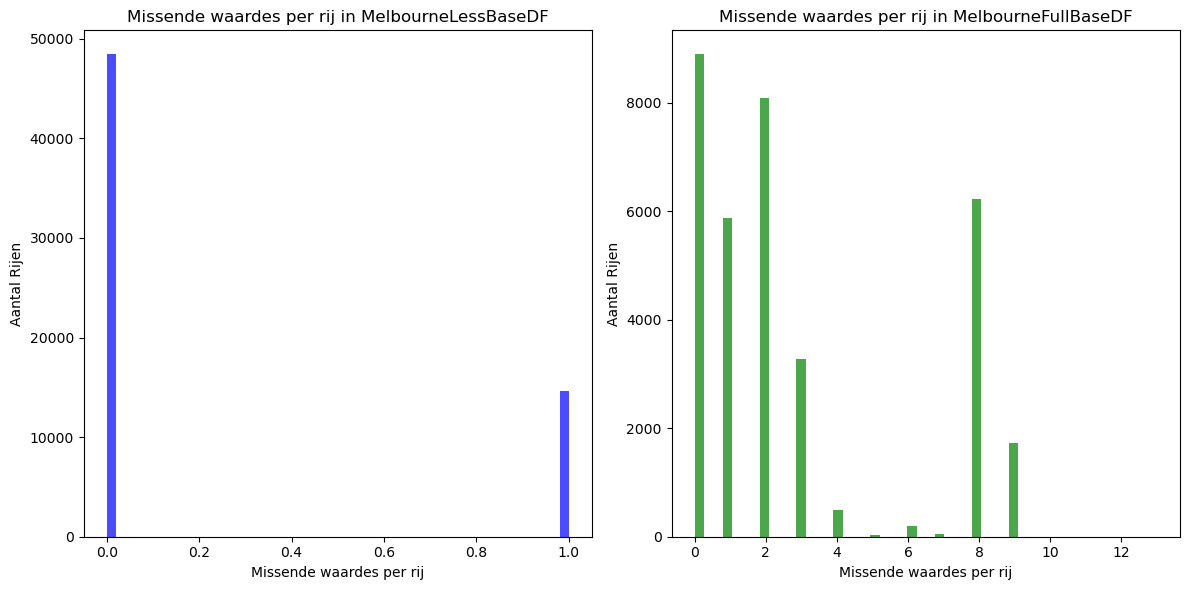

In [15]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(missing_per_row_less, bins=50, color='blue', alpha=0.7)
plt.title('Missende waardes per rij in MelbourneLessBaseDF')
plt.xlabel('Missende waardes per rij')
plt.ylabel('Aantal Rijen')

plt.subplot(1, 2, 2)
plt.hist(missing_per_row_full, bins=50, color='green', alpha=0.7)
plt.title('Missende waardes per rij in MelbourneFullBaseDF')
plt.xlabel('Missende waardes per rij')
plt.ylabel('Aantal Rijen')

plt.tight_layout()
plt.show()

De figuren laten duidelijk zien hoe de verdeling van missende waardes er uit ziet per dataset.

In het "Snapshot" bevat het merendeel totaal geen missende waardes, en is er nooit meer dan één missende waarde aanwezig binnenin de rijen die wel iets missen.

In de "Complete" dataset is er een veel grotere verspreiding waar te nemen, deze zal verder worden uitgelicht in de volgende tabel:

In [17]:
missing_per_row_full = MelbourneFullBaseDF.isnull().sum(axis=1)

missing_value_counts = missing_per_row_full.value_counts().sort_index()

missing_percentage = (missing_value_counts / total_rows_full) * 100

missing_table = pd.DataFrame({
    'Missende Waardes': missing_value_counts.index,
    'Aantal': missing_value_counts.values,
    'Percentage': missing_percentage.values
})

missing_table['Percentage'] = missing_table['Percentage'].apply(lambda x: f"{x:.2f}%")

missing_table = missing_table[missing_table['Missende Waardes'] <= 12]

display(missing_table)

,Missende Waardes,Aantal,Percentage
0,0,8887,25.50%
1,1,5867,16.83%
2,2,8083,23.19%
3,3,3280,9.41%
4,4,496,1.42%
5,5,32,0.09%
6,6,205,0.59%
7,7,57,0.16%
8,8,6229,17.87%
9,9,1718,4.93%


Deze verdeling versterkt de eerdere waarneming dat een redelijk groot aantal van de rijen minder dan drie missende waardes bevatten.

Het probleem is echter dat er opeens een grote piek ontstaat bij de waarneming van 8 missende waardes, dit nummer is belangrijk omdat we eerder hebben geconstateerd dat de "complete" dataset 8 kolommen bevat die niet voorkomen in het "snapshot".

De volgende handeling zal eerst het aantal rijen met precies 8 missende waardes filteren, waarna er wordt weergegeven bij welke kolommen dit voorkomt.
Indien het resultaat meer dan acht kolomnamen weergeeft, kan er verder onderzoek worden gedaan naar de percentuele verdeling van deze kolommen, maar als het acht specifieke namen zijn dan kunnen er meer conclusies worden getrokken over de rollen van de datasets.

In [19]:
rows_with_8_missing = MelbourneFullBaseDF[missing_per_row_full == 8]

columns_with_missing_values = rows_with_8_missing.columns[rows_with_8_missing.isnull().any()]

sorted_columns_with_missing_values = sorted(columns_with_missing_values)

missing_columns_df = pd.DataFrame(sorted_columns_with_missing_values, columns=['Kolommen met missende waardes'])

missing_columns_df.reset_index(drop=True, inplace=True)

display(missing_columns_df)

,Kolommen met missende waardes
0,Bathroom
1,Bedroom2
2,BuildingArea
3,Car
4,Landsize
5,Lattitude
6,Longtitude
7,YearBuilt


Het weergegeven resultaat bestaat uit precies acht kolommen, deze zouden meer inzicht kunnen geven wanneer er geconstateerd wordt of deze kolommen alleen toebehoren tot de "complete" dataset.

Om hier achter te komen worden de kolomnamen van beiden datasets met elkaar vergeleken, waarna er een lijst wordt uitgedraaid waarin de namen van de acht kolommen staan die niet in het "snapshot" staan.

In [21]:
columns_less = set(MelbourneLessBaseDF.columns)
columns_full = set(MelbourneFullBaseDF.columns)

only_in_full = sorted(list(columns_full - columns_less))

columns_comparison = pd.DataFrame({
    'Alleen in de Complete Dataset': only_in_full
})

columns_comparison.reset_index(drop=True, inplace=True)

display(columns_comparison)

,Alleen in de Complete Dataset
0,Bathroom
1,Bedroom2
2,BuildingArea
3,Car
4,Landsize
5,Lattitude
6,Longtitude
7,YearBuilt


De lijst met kolomnamen die voorkomen in rijen met precies 8 missende waardes komt geheel overeen met de lijst van kolommen die alleen in de "complete" dataset staan.

Dit suggereert dat deze kolommen mogelijk veel uit missende waardes bevatten, waardoor de verschillende rijen dus ook al sneller een missende waarde bevatten.

Om dit te testen zijn de acht kolommen samengevoegd als een entiteit "Groep 1", en is hetzelfde gedaan met de overige 15 kolommen in de vorm van "Groep 2". Hierna is er naar elke rij gekeken die een specifiek aantal missende waardes heeft, waarna er is gekeken hoeveel van die missende waardes onder welke groep vallen, en hoe deze dan in verhouding met elkaar staan.

In [23]:
group_1_columns = ['Bathroom', 'Bedroom2', 'BuildingArea', 'Car', 'Landsize', 'Lattitude', 'Longtitude', 'YearBuilt']
group_2_columns = [col for col in MelbourneFullBaseDF.columns if col not in group_1_columns]

df = MelbourneFullBaseDF.copy()

missing_in_group_1 = df[group_1_columns].isnull()
missing_in_group_2 = df[group_2_columns].isnull()

df['MissingCount'] = missing_in_group_1.sum(axis=1) + missing_in_group_2.sum(axis=1)

missing_proportions = pd.DataFrame(columns=['Groep 1', 'Groep 2'], index=range(1, 12))

for missing_count in range(1, 12):
    rows_with_missing = df[df['MissingCount'] == missing_count]
    
    group_1_missing = missing_in_group_1.loc[rows_with_missing.index].sum(axis=1).sum()
    group_2_missing = missing_in_group_2.loc[rows_with_missing.index].sum(axis=1).sum()
    
    total_missing = group_1_missing + group_2_missing
    if total_missing > 0:
        group_1_percentage = (group_1_missing / total_missing) * 100
        group_2_percentage = (group_2_missing / total_missing) * 100
    else:
        group_1_percentage = group_2_percentage = 0
        
    missing_proportions.loc[missing_count, 'Groep 1'] = f"{group_1_percentage:.2f}%"
    missing_proportions.loc[missing_count, 'Groep 2'] = f"{group_2_percentage:.2f}%"

display(missing_proportions)

,Groep 1,Groep 2
1,55.17%,44.83%
2,94.73%,5.27%
3,80.59%,19.41%
4,78.98%,21.02%
5,85.00%,15.00%
6,99.84%,0.16%
7,85.71%,14.29%
8,100.00%,0.00%
9,88.89%,11.11%
10,0.00%,0.00%


De bovenstaande weergave laat zien dat een heel groot aantal van missende waardes altijd bestaat uit een missende waarde binnenin 1 van de 8 kolommen binnnenin de "complete" dataset, wat dus inderdaad de indicatie geeft dat deze kolommen inderdaad de grootste reden zijn voor het aantal missende waardes binnenin de "complete" dataset.

Mogelijk is het "Snapshot" gebaseerd op de dataset zonder deze specifieke kolommen, en zijn er meer rijen gegenereerd gebaseerd op bestaande data.

Ondanks het feit dat het "Snapshot" een completere dataset is, past de "Complete" dataset meer bij het doel wat er voor ogen is, in dat meer kolommen meer mogelijkheden tot regressie aanbieden.

Om deze reden zal er in dit notebook verder worden gewerkt met de "Melbourne_housing_FULL" dataset, oftewel het "MelbourneFullBaseDF" Dataframe.

<h2><b>Melbourne Housing FULL</b></h2>

Er is al gekeken naar de vorm en omschrijving van deze dataset, maar het is ook belangrijk om in te zien hoe de specifieke kolommen er uit zien, en wat voor verschillende waardes er in elke kolom kunnen staan.

Op deze manier kan er in een oogopslag worden gezien of er mogelijk iets mis is met het datatype of de manier waarop een waarde is neergeschreven binnnenin een specifieke kolom:

In [26]:
MelbourneFullBaseDF.dtypes

Suburb            object
Address           object
Rooms              int64
Type              object
Price            float64
Method            object
SellerG           object
Date              object
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea       object
Lattitude        float64
Longtitude       float64
Regionname        object
Propertycount    float64
dtype: object

In [27]:
MelbourneFullBaseDF.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In een oogopslag lijkt alles acceptabel te zijn, al zijn er een aantal kleine opvallende waarnemingen die niet perse veel uitmaken voor de regressie, maar wel even worden gecorrigeerd voor gebruik in algoritmes:

- Numerieke kolommen zouden consistent moeten zijn: "Rooms", "Car", "Bedroom2", "Propertycount", en "Bathroom" zijn allemaal kolommen die een aantal zonder decimaal aangeven, wat betekend dat deze ook hetzelfde datatype zouden moeten hebben. Er kan namelijk geen anderhalve badkamer, of auto gedefinieerd worden, wat betekend dat deze allemaal integers zijn.
- Sommige numerieke kolommen bevatten geen nummers waarmee calculaties worden gedaan: "Postcode" en "YearBuilt" bestaan beiden uit nummers die eerder als een string moeten worden gezien.
- Datums zouden een Datetime formaat moeten hebben: Dit betekend dat "Date" geconverteerd zou moeten worden.
- Een foutieve naam voor "latitude" en "longitude" in dat er in beiden woorden een extra "-t" staat.

In [29]:
MelbourneFullBaseDF["Date"] = pd.to_datetime(MelbourneFullBaseDF["Date"],dayfirst=True)

In [30]:
print("Datatype van 'Date' kolom:", MelbourneFullBaseDF['Date'].dtype)

print(MelbourneFullBaseDF['Date'].head())

Datatype van 'Date' kolom: datetime64[ns]
0   2016-09-03
1   2016-12-03
2   2016-02-04
3   2016-02-04
4   2017-03-04
Name: Date, dtype: datetime64[ns]


Bovenstaande code heeft de originele datums omgezet naar een ISO 8601 formaat, waarna deze ook geprint zijn om te checken of de structuur nog correct is.

Eenzelfde methode zal nu gebruikt worden om de datatypes van de telbare numerieke kolommen om te zetten naar Integers. Ondanks het feit dat er al een aantal kolommen waren uitgelicht, zal er een code worden gebruikt om te bepalen welke kolommen een Float datatype moeten behouden, en welke gewoonweg een Integer kunnen zijn.

Hiervoor wordt er gekeken in elke kolom, en wordt er uitgelicht of er een decimaal (anders dan 0) aanwezig is, als dit het geval is, dan wordt deze kolom neergeschreven.

In [32]:
numeric_columns = MelbourneFullBaseDF.select_dtypes(include=["number"]).columns

for col in numeric_columns:
    decimal_rows = MelbourneFullBaseDF[pd.notna(MelbourneFullBaseDF[col]) & (MelbourneFullBaseDF[col] % 1 != 0)]
    
    if not decimal_rows.empty:
        print(f"Kolom '{col}' heeft decimale waardes")

Kolom 'Distance' heeft decimale waardes
Kolom 'BuildingArea' heeft decimale waardes
Kolom 'Lattitude' heeft decimale waardes
Kolom 'Longtitude' heeft decimale waardes


Dit betekend dat de volgende kolommen geconverteerd moeten worden naar een Integer:

- Price
- Bedroom2
- Bathroom
- Car
- Landsize
- Propertycount
- YearBuilt (Dit is een geheel jaartal, en maakt dus geen gebruik van het datetime formaat)

De overige numerieke kolom "Postcode" wordt ook geconverteerd naar een Integer om het decimaal weg te halen, daarna wordt deze verder geconverteerd naar een String.

In [34]:
columns_to_convert = ["Price", "Bedroom2", "Bathroom", "Car", "Landsize", "Propertycount", "YearBuilt", "Postcode"]

for col in columns_to_convert:
    if col in MelbourneFullBaseDF.columns:
        MelbourneFullBaseDF[col] = MelbourneFullBaseDF[col].astype("Int64")

print(MelbourneFullBaseDF[columns_to_convert].dtypes)

Price            Int64
Bedroom2         Int64
Bathroom         Int64
Car              Int64
Landsize         Int64
Propertycount    Int64
YearBuilt        Int64
Postcode         Int64
dtype: object


In [35]:
MelbourneFullBaseDF['Postcode'] = MelbourneFullBaseDF['Postcode'].astype(str)
print(MelbourneFullBaseDF['Postcode'])

0        3067
1        3067
2        3067
3        3067
4        3067
         ... 
34852    3013
34853    3013
34854    3013
34855    3013
34856    3013
Name: Postcode, Length: 34857, dtype: object


Tenslotte zullen "Lattitude" en "Longtitude" hernoemd worden naar "Latitude" en "Longitude", gewoonweg zodat deze spelfouten niet steeds terugkomen.

In [37]:
MelbourneFullBaseDF.rename(columns={'Lattitude': 'Latitude', 'Longtitude': 'Longitude'}, inplace=True)

In [38]:
MelbourneFullBaseDF.dtypes

Suburb                   object
Address                  object
Rooms                     int64
Type                     object
Price                     Int64
Method                   object
SellerG                  object
Date             datetime64[ns]
Distance                float64
Postcode                 object
Bedroom2                  Int64
Bathroom                  Int64
Car                       Int64
Landsize                  Int64
BuildingArea            float64
YearBuilt                 Int64
CouncilArea              object
Latitude                float64
Longitude               float64
Regionname               object
Propertycount             Int64
dtype: object

In [39]:
MelbourneFullBaseDF.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Latitude,Longitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,<NA>,SS,Jellis,2016-09-03,2.5,3067,...,1,1,126,NaN,<NA>,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019
1,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,2016-12-03,2.5,3067,...,1,1,202,NaN,<NA>,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019
2,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,2016-02-04,2.5,3067,...,1,0,156,79.0,1900,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019
3,Abbotsford,18/659 Victoria St,3,u,<NA>,VB,Rounds,2016-02-04,2.5,3067,...,2,1,0,NaN,<NA>,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019
4,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,2017-03-04,2.5,3067,...,2,0,134,150.0,1900,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019


De dataset bevat nu de correcte datatypes voor elke kolom, wat er voor zorgt dat elke waarde nu ook correct is neergeschreven.

Zoals eerder is aangegeven, bevat deze dataset een heel aantal missende waardes, vooral voortkomend uit de acht extra kolommen. Gezien deze kolommen belangrijk zijn voor de toepassing van regressie, is het belangrijk dat er gebruik wordt gemaakt van imputatie om deze waardes in te vullen.

Allereerst zullen alle kolommen nogmaals worden weergegeven, waarna er wordt gekeken welke kolommen imputatie nodig hebben, en op welke manier dat wordt gedaan.

In [41]:
missing_info = MelbourneFullBaseDF.isnull().sum().to_frame(name="Missing Values")
missing_info["Total Rows"] = len(MelbourneFullBaseDF)
missing_info["Percentage"] = (missing_info["Missing Values"] / missing_info["Total Rows"]) * 100

missing_info["Percentage"] = missing_info["Percentage"].map(lambda x: f"{x:.2f}%")
missing_info = missing_info.sort_values(by="Missing Values", ascending=False)

print(missing_info)

               Missing Values  Total Rows Percentage
BuildingArea            21115       34857     60.58%
YearBuilt               19306       34857     55.39%
Landsize                11810       34857     33.88%
Car                      8728       34857     25.04%
Bathroom                 8226       34857     23.60%
Bedroom2                 8217       34857     23.57%
Longitude                7976       34857     22.88%
Latitude                 7976       34857     22.88%
Price                    7610       34857     21.83%
Regionname                  3       34857      0.01%
CouncilArea                 3       34857      0.01%
Propertycount               3       34857      0.01%
Distance                    1       34857      0.00%
Address                     0       34857      0.00%
Postcode                    0       34857      0.00%
Date                        0       34857      0.00%
SellerG                     0       34857      0.00%
Method                      0       34857     

Op basis van bovenstaande informatie zijn de volgende handelingen beredeneerd:

- Kolommen met 0.01% missende waardes zullen worden ingevuld met een simpele imputatie in de vorm van "gemiddelde" of "meest voorkomend".
- Kolommen met tussen de 20% - 50% missende waardes zullen worden ingevuld met imputatiemethodes zoals "gemiddelde" en "regressie", of worden gebaseerd op de waardes binnenin andere kolommen.
- Kolommen die meer dan 50% missende waardes bevatten zullen beter worden bekeken om te besluiten wat daarmee gedaan gaat worden, hierbij wordt vooral gekeken of deze genoeg bij gaan dragen aan de latere regressie machine learning.

<h2><b><1% Missende Waardes</b></h2>

Deze kolommen bevatten maar een ontzettend klein aantal missende waardes, die vrijwel geen verschil gaan maken in de functie van de regressie machine learning. Om deze reden kan hier een simpele imputatie functie voor worden gebruikt, waarbij de categorische kolommen de meest voorkomende waarde krijgen, terwijl de numerieke kolommen de gemiddelde waarde krijgen.

Tenslotte wordt na deze imputatie gecheckt of er nog missende waardes voorkomen in deze kolommen.

In [43]:
categorical_columns = ['Regionname', 'CouncilArea']
numerical_columns = ['Propertycount', 'Distance']

categorical_imputer = SimpleImputer(strategy='most_frequent')

numerical_imputer = SimpleImputer(strategy='mean')

MelbourneFullBaseDF[categorical_columns] = categorical_imputer.fit_transform(MelbourneFullBaseDF[categorical_columns])

MelbourneFullBaseDF[numerical_columns] = numerical_imputer.fit_transform(MelbourneFullBaseDF[numerical_columns])

print(MelbourneFullBaseDF[categorical_columns + numerical_columns].isnull().sum())

Regionname       0
CouncilArea      0
Propertycount    0
Distance         0
dtype: int64


<h2><b>20% - 50% Missende Waardes</b></h2>

Dit zijn de telbare kolommen in de vorm van "Car", "Bathroom", en "Bedroom2", locatie-gerelateerde data in de vorm van breedte- en lengtegraad, oppervlakte-gerelateerde kolommen in de vorm van Landsize, en het uiteindelijke doel voor de regressie in de vorm van de woonprijs.

De telbare kolommen zijn heel belangrijk in het vaststellen van regressie, omdat het logisch is dat het bevatten van meer ruimtes en voorzieningen betekend dat de prijs van een huis omhoog kan gaan.

De prijs gaat niet geïmputeerd worden, hierop wordt namelijk de Machine-Learning toegepast. Omdat er maar 20% mist, zal dit weinig problemen geven.

<b>Car</b>

De enige telbare kolom die echter geen tot weinig waarde voor de regressie lijkt te hebben is "Car", de waardes in deze kolom zijn meestal 1 of 2, en zijn onduidelijk in wat deze waarde nu uiteindelijk betekend. Om deze redenen zal een simpele imputatie methode worden gebruikt in de vorm van een willekeurige invulling gebaseerd op de bestaande waardes in de dataset.

Hiervoor zullen eerst alle waardes in de "Car" kolom die niet missen worden geëvalueerd, waarna de missende waardes willekeurig worden ingevuld gebaseerd op deze waardes.

In [45]:
existing_values = MelbourneFullBaseDF['Car'].dropna().values

MelbourneFullBaseDF.loc[MelbourneFullBaseDF['Car'].isna(), 'Car'] = np.random.choice(existing_values, 
                                                                                              size=MelbourneFullBaseDF['Car'].isna().sum(), 
                                                                                              replace=True).astype(float)

De volgende stap in het imputatieproces voor deze sectie is gebaseerd op hoe veel bewerkingen moeten worden gedaan, momenteel zijn de breedte- en lengtegraad te baseren op de CouncilArea en Suburb, beiden missen geen waardes en zouden dus makkelijk de mogelijkheid kunnen aanbieden om een preciese imputatie te implementeren.

<b>Latitude & Longitude</b>

De breedte- en lengtegraad kolommen kunnen mogelijk makkelijk in worden gevuld indien alle waardes hetzelfde zijn voor bepaalde voorsteden en de bijbehorende disctrictsraad, dit zal dan ook eerst onderzocht worden voordat er een imputatie methode wordt toegepast.

Hiervoor zal eerst worden bekeken hoeveel unieke voorsteden aanwezig zijn, en daarna hoeveel unieke coördinaten aanwezig zijn. Als deze overeenkomen kunnen de missende waardes, na een controle, gewoonweg in worden gevuld gebaseerd op locatie.

In [47]:
unique_suburbs = MelbourneFullBaseDF['Suburb'].nunique()

unique_coordinates = MelbourneFullBaseDF[['Longitude', 'Latitude']].dropna().nunique()

print(f"Aantal unieke suburbs: {unique_suburbs}")
print(f"Aantal unieke coördinaatcombinaties: {unique_coordinates}")

Aantal unieke suburbs: 351
Aantal unieke coördinaatcombinaties: Longitude    14524
Latitude     13402
dtype: int64


Deze bevinding geeft aan dat er niet alleen dezelfde combinatie van coördinaten passen bij elke unieke voorstad.

De volgende stap is om te bekijken hoe de coördinaten passen bij de verschillende regio's. indien er te zien is dat elke regio een bepaald bereik aan coördinaten heeft, dan is het makkelijker om hiermee een specifiekere imputatie toe te passen.

Hiervoor zal dus eerst in kaart worden gebracht hoe de verspreiding van coördinaten er uit ziet per regio.

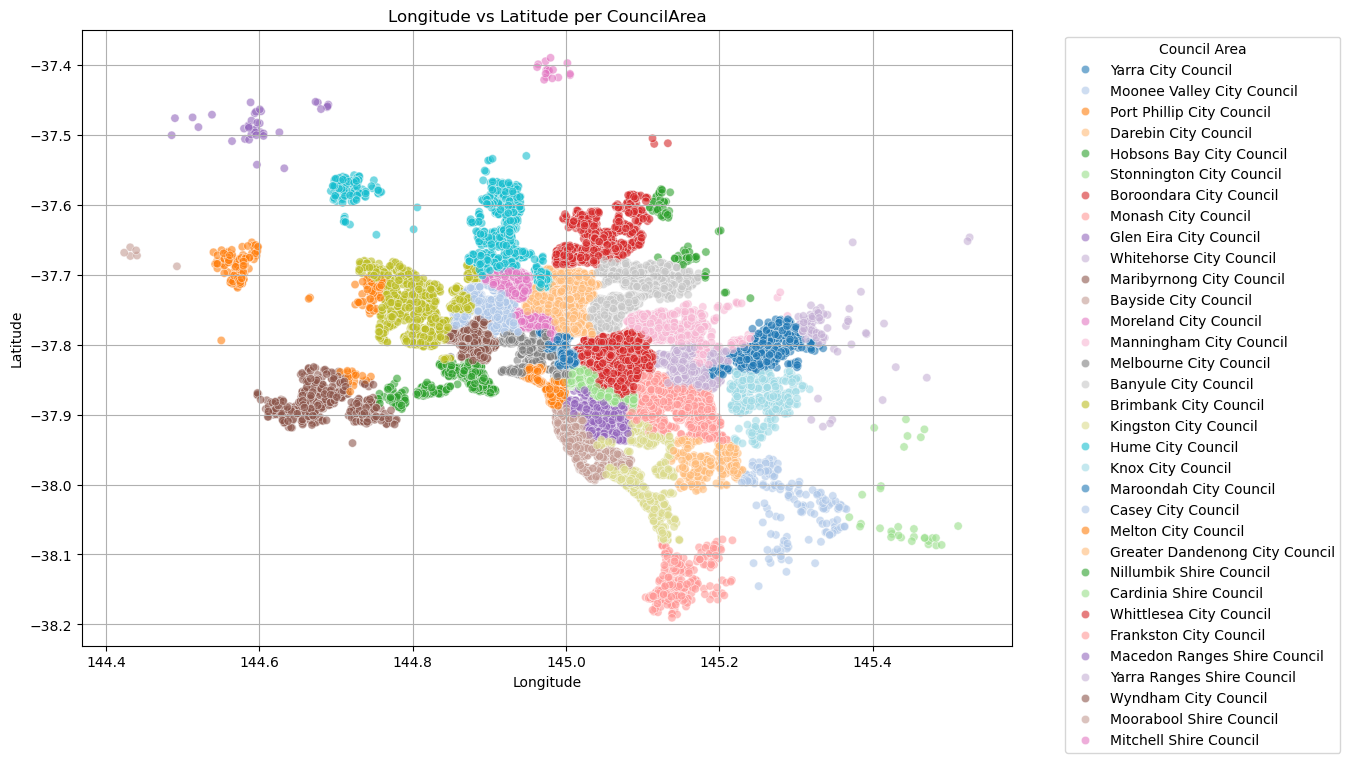

In [49]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=MelbourneFullBaseDF,
    x="Longitude",
    y="Latitude",
    hue="CouncilArea",
    palette="tab20",
    alpha=0.6
)

plt.title("Longitude vs Latitude per CouncilArea")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Council Area", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

plt.show()

In een oogopslag lijken de waardes niet te overlappen, al is het beter om dit na te gaan met een code die aangeeft of er ergens een overlap is.

Voor deze code worden de coördinaten per regio gegroepeerd, waarna coördinaten combinaties die maar 1 keer voorkomen niet worden overwogen.
Als er coördinaten over blijven, worden deze geprint samen met de voorsteden en regio's waarin deze voorkomen, zo niet dan zijn er geen duplicaten.

In [51]:
overlap_df = MelbourneFullBaseDF.groupby(['Longitude', 'Latitude'])['CouncilArea'].nunique().reset_index(name='CouncilAreaCount')

overlap_df = overlap_df[overlap_df['CouncilAreaCount'] > 1]

if not overlap_df.empty:
    example_overlap = overlap_df.iloc[0]
    longitude = example_overlap['Longitude']
    latitude = example_overlap['Latitude']
    
    overlapping_rows = MelbourneFullBaseDF[(MelbourneFullBaseDF['Longitude'] == longitude) & 
                                           (MelbourneFullBaseDF['Latitude'] == latitude)]
    
    print(f"Overlapping Coordinates: Longitude = {longitude}, Latitude = {latitude}")
    print("Unieke Council Areas met overlappende coördinaten:")
    print(overlapping_rows[['Suburb', 'CouncilArea']].drop_duplicates())
else:
    print("Geen overlappende coördinaten gevonden binnenin unieke council areas.")

Geen overlappende coördinaten gevonden binnenin unieke council areas.


Omdat bovenstaande code aangeeft dat er geen overlap in unieke coördinaten plaatsvind in de unieke regio's, loont het om nogmaals de verschillende voorsteden per regio te bekijken, om te achterhalen of deze ook unieke coördinaten bevat. Wanneer hier namelijk uitkomt of dit wel of niet het geval is, wordt het makkelijker om een imputatiemethode toe te passen.

De volgende code zal eerst aangeven of een voorstad aanwezig is in meerdere regio's, waarna een specifieke regio als voorbeeld wordt gebruikt om de verdeling van coördinaten binnenin de bijbehorende voorsteden weer te geven. 

In [53]:
suburb_council_areas = MelbourneFullBaseDF.groupby('Suburb')['CouncilArea'].unique()

suburbs_multiple_areas = suburb_council_areas[suburb_council_areas.apply(lambda x: len(x) > 1)]

print("Voorsteden die binnen meerdere regio's vallen:")
for suburb, council_areas in suburbs_multiple_areas.items():
    print(f"{suburb}: {', '.join(council_areas)}")

Voorsteden die binnen meerdere regio's vallen:
Footscray: Maribyrnong City Council, Boroondara City Council


Omdat er maar een voorstad is die onder meerdere regio's valt, en omdat deze dataset is gebaseerd op de werkelijkheid, is het heel makkelijk om gewoonweg te achterhalen in welke regio deze voorstad daadwerkelijk valt, zodat het eerdere plan kan worden uitgevoerd.

Online is al heel snel te vinden dat Footscray deel uitmaakt van Maribyrnong, wat betekend dat deze eerst moet worden aangepast in de data voordat het plan wordt voortgezet.

In [55]:
rows_to_change = MelbourneFullBaseDF[(MelbourneFullBaseDF['Suburb'] == 'Footscray') & 
                                     (MelbourneFullBaseDF['CouncilArea'] == 'Boroondara City Council')]

MelbourneFullBaseDF.loc[(MelbourneFullBaseDF['Suburb'] == 'Footscray') & 
                        (MelbourneFullBaseDF['CouncilArea'] == 'Boroondara City Council'), 'CouncilArea'] = 'Maribyrnong City Council'

print(f"Aantal veranderde rijen: {len(rows_to_change)}")

Aantal veranderde rijen: 1


Uit deze code is bevonden dat er een foutieve waarde in deze dataset stond gebaseerd op voorstad locatie, wat tegelijkertijd ook bevestigd dat de voorsteden dus ook daadwerkelijk correct zijn ingevuld bij de relevante regio.

Deze bevinding insinueerd dat de volgende stap, het koppelen van voorsteden aan een bereik van coördinaten, ook zal gaan werken.
Deze bewerking zal er voor zorgen dat al deze missende waardes voor breedte- en lengtegraad op een correcte manier worden geïmputeerd.

De volgende code geeft vier willekeurige scatterplot weer van 1 gemeente met de bijbehorende voorsteden, om te checken hoe deze gegenereerd worden.

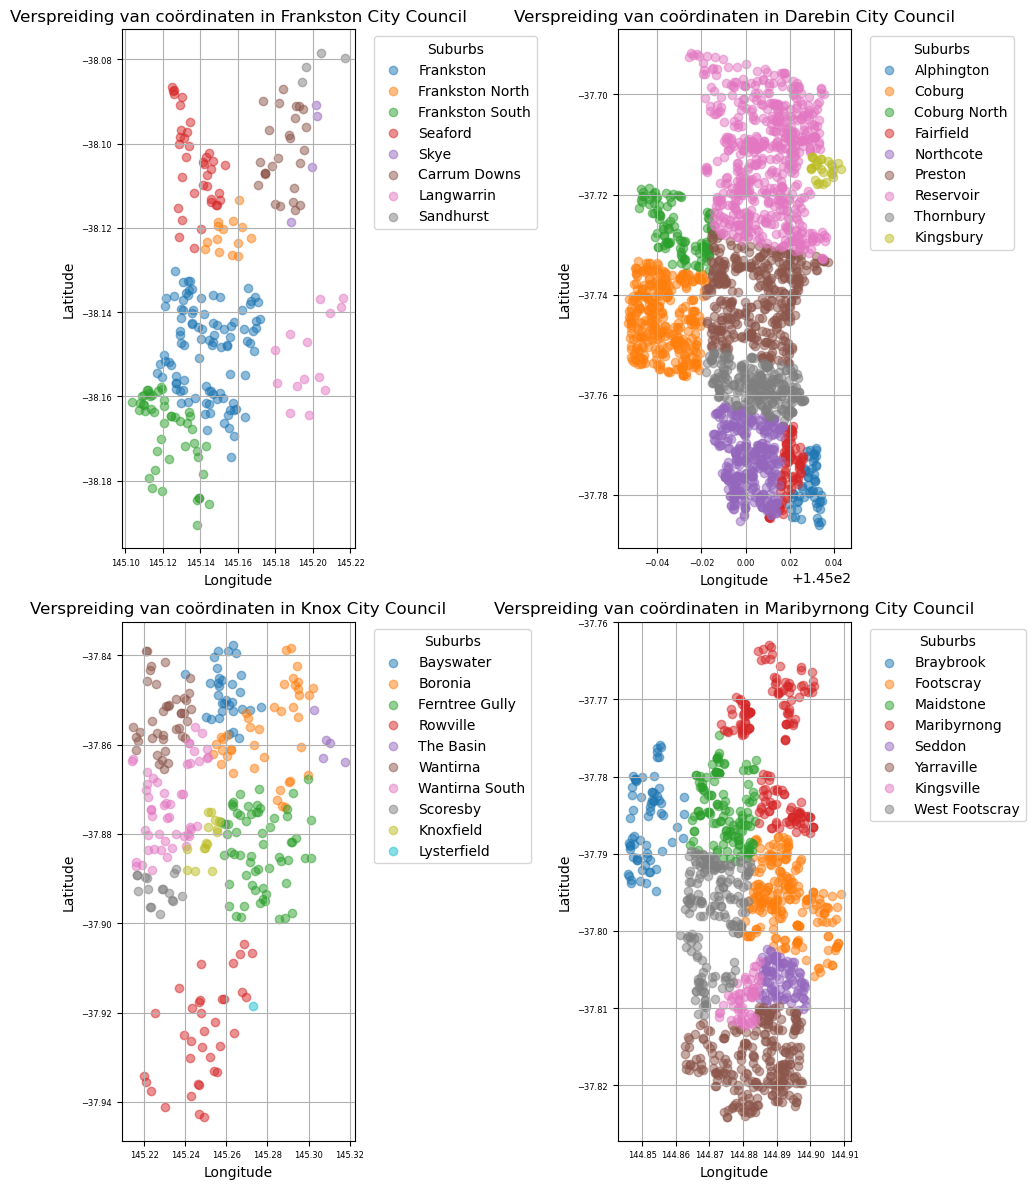

In [57]:
unique_councilareas = MelbourneFullBaseDF['CouncilArea'].unique()

random_councilareas = random.sample(list(unique_councilareas), 4)

plt.figure(figsize=(10, 12))

for i, council_area in enumerate(random_councilareas, 1):
    plt.subplot(2, 2, i)
    
    council_df = MelbourneFullBaseDF[MelbourneFullBaseDF['CouncilArea'] == council_area]
    
    for suburb in council_df['Suburb'].unique():
        suburb_data = council_df[council_df['Suburb'] == suburb]
        plt.scatter(suburb_data['Longitude'], suburb_data['Latitude'], label=suburb, alpha=0.5)
    
    plt.title(f'Verspreiding van coördinaten in {council_area}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend(title='Suburbs', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tick_params(axis='both', labelsize=6)

plt.tight_layout()
plt.show()

Net zoals voor de regio's is er niet met zekerheid te zeggen of er overlappende waardes zijn, waardoor er weer een code moet worden geschreven om dit te checken.

Indien er geen overlap is, zal het volgende gedeelte over de imputatie van missende waardes gaan.

In [59]:
overlap_df = MelbourneFullBaseDF.groupby(['Longitude', 'Latitude', 'Suburb'])['CouncilArea'].nunique().reset_index(name='CouncilAreaCount')

overlap_df = overlap_df[overlap_df['CouncilAreaCount'] > 1]

if not overlap_df.empty:
    example_overlap = overlap_df.iloc[0]
    longitude = example_overlap['Longitude']
    latitude = example_overlap['Latitude']
    overlapping_rows = MelbourneFullBaseDF[(MelbourneFullBaseDF['Longitude'] == longitude) & 
                                           (MelbourneFullBaseDF['Latitude'] == latitude) & 
                                           (MelbourneFullBaseDF['Suburb'] == example_overlap['Suburb'])]
    
    print(f"Overlapping Coordinates: Longitude = {longitude}, Latitude = {latitude}")
    print("Overlappende Voorsteden met coördinaten:")
    print(overlapping_rows[['Suburb', 'CouncilArea']].drop_duplicates())
else:
    print("Geen overlappende coördinaten gevonden binnenin unieke voorsteden.")

Geen overlappende coördinaten gevonden binnenin unieke voorsteden.


Omdat ook deze code aangeeft dat er geen overlappende waardes aanwezig zijn, is het mogelijk om de missende coördinaten te imputeren.

Om deze imputatie te realiseren worden de missende waardes uitgelicht, waarna deze worden ingevuld op basis van de gemiddelde waarde van de coördinaten gebaseerd op de respectieve voorstad.

Deze veranderingen worden toegepast op het huidige dataframe, waarna er wordt gecontroleerd of deze veranderingen ook succesvol zijn uitgevoerd doormiddel van het opnieuw printen van missende waardes binnenin de "Longitude" en "Latitude" kolommen.

In [61]:
mean_coordinates = MelbourneFullBaseDF.groupby('Suburb')[['Longitude', 'Latitude']].mean()

def impute_coordinates(row):
    if pd.isnull(row['Longitude']):
        row['Longitude'] = mean_coordinates.loc[row['Suburb'], 'Longitude']
    if pd.isnull(row['Latitude']):
        row['Latitude'] = mean_coordinates.loc[row['Suburb'], 'Latitude']
    return row

MelbourneFullBaseDF = MelbourneFullBaseDF.apply(impute_coordinates, axis=1)

print(MelbourneFullBaseDF[['Suburb', 'Longitude', 'Latitude']].isnull().sum())

Suburb        0
Longitude    88
Latitude     88
dtype: int64


Ondanks het feit dat de "Suburb" kolom totaal geen missende waardes bevat, is de imputatie niet volledig succesvol om een of andere reden.

Om na te gaan wat het probleem is, zullen er meerdere onderzoekende methodes gebruikt worden of dit te achterhalen.
Ten eerste zal er worden gecheckt of deze waardes te maken hebben met een specifieke voorstad.

In [63]:
missing_data_by_suburb = MelbourneFullBaseDF[MelbourneFullBaseDF[['Longitude', 'Latitude']].isna().any(axis=1)].groupby('Suburb').size()
print(missing_data_by_suburb)

Suburb
Cranbourne East     1
Fawkner Lot         1
MacLeod            83
Olinda              1
croydon             1
viewbank            1
dtype: int64


Uit deze resultaten valt af te lezen dat vijf van de zes benoemde voorsteden allemaal maar 1 keer voorkomen, mogelijk zijn dit dus voorsteden die maar een keer vookomen in de gehele dataset, en daardoor geen andere rijen als referentie hadden om de waardes in te vullen op basis van de imputatie.

Om dit te checken zal er voor deze voorsteden worden gekeken hoe vaak deze voorkomen in de dataset.

In [65]:
suburb_counts = MelbourneFullBaseDF['Suburb'].value_counts()

specific_suburbs = ['Cranbourne East', 'Fawkner Lot', 'MacLeod', 'Olinda', 'croydon', 'viewbank']
print(suburb_counts[specific_suburbs])

Suburb
Cranbourne East     1
Fawkner Lot         1
MacLeod            83
Olinda              1
croydon             1
viewbank            1
Name: count, dtype: int64


Deze waarneming laat inderdaad zien dat deze voorsteden maar een aantal keer voorkomen, waardoor er geen andere referentie is voor de imputatie.

Alleen MacLeod heeft een groter aantal missende waardes en voorkomingen, maar in het grote geheel is dit ook maar ~0.24% van alle data.

Omdat deze data niet veel invloed gaan hebben op toekomstige berekeningen, is het plan nu om de imputatie niet te baseren op de gemiddelde waarde van de desbetreffende voorstad, maar een stapje omlaag te gaan en het te laten baseren op de desbetreffende regio.

Deze handeling zal niet voor enige problemen zorgen omdat het niet veel data betreft en nog steeds redelijk nauwkeurige data imputeert die overeenkomt met de regio.

In [67]:
council_area_avg = MelbourneFullBaseDF.groupby('CouncilArea')[['Longitude', 'Latitude']].mean()
MelbourneFullBaseDF['Longitude'] = MelbourneFullBaseDF['Longitude'].fillna(MelbourneFullBaseDF['CouncilArea'].map(council_area_avg['Longitude']))
MelbourneFullBaseDF['Latitude'] = MelbourneFullBaseDF['Latitude'].fillna(MelbourneFullBaseDF['CouncilArea'].map(council_area_avg['Latitude']))

print(MelbourneFullBaseDF[['Longitude', 'Latitude']].isnull().sum())

Longitude    0
Latitude     0
dtype: int64


Al deze uitvoeringen hebben ervoor gezorgd dat de missende waardes binnenin de "longitude" en "latitude" kolommen allemaal zijn ingevuld gebaseerd op de gemiddelde waarde van de desbetreffende voorstad, en voor de unieke gevallen, de gemiddelde waarde van de desbetreffende regio.

Deze handelingen zorgen ervoor dat er een nauwkeurige machine learning kan worden toegepast om zo een relatie te ontdekken tussen de prijs van huizen en de locatie van deze huizen.

<b>Rooms</b>

In [70]:
MelbourneFullBaseDF['Bedrooms per room'] = MelbourneFullBaseDF['Bedroom2'] / MelbourneFullBaseDF['Rooms']
 
mean_bedrooms_per_sqm = MelbourneFullBaseDF['Bedrooms per room'].mean()

MelbourneFullBaseDF['Bedroom2'].fillna(MelbourneFullBaseDF['Rooms'] * mean_bedrooms_per_sqm, inplace=True)

MelbourneFullBaseDF['Bedroom2'] = MelbourneFullBaseDF['Bedroom2'].round()

MelbourneFullBaseDF.drop(columns=['Bedrooms per room'], inplace=True)

display(MelbourneFullBaseDF[['Bedroom2', 'Rooms']].head(10))

C:\Users\luukk\AppData\Local\Temp\ipykernel_22812\2868467641.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  MelbourneFullBaseDF['Bedroom2'].fillna(MelbourneFullBaseDF['Rooms'] * mean_bedrooms_per_sqm, inplace=True)
C:\Users\luukk\AppData\Local\Temp\ipykernel_22812\2868467641.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_do

,Bedroom2,Rooms
0,2.0,2
1,2.0,2
2,2.0,2
3,3.0,3
4,3.0,3
5,3.0,3
6,3.0,4
7,3.0,4
8,4.0,2
9,3.0,2


<b>Bathroom</b>

In [72]:
MelbourneFullBaseDF['Bathrooms per room'] = MelbourneFullBaseDF['Bathroom'] / MelbourneFullBaseDF['Rooms']
 
mean_bedrooms_per_sqm = MelbourneFullBaseDF['Bathrooms per room'].mean()

MelbourneFullBaseDF['Bathroom'].fillna(MelbourneFullBaseDF['Rooms'] * mean_bedrooms_per_sqm, inplace=True)

MelbourneFullBaseDF['Bathroom'] = MelbourneFullBaseDF['Bathroom'].round()

MelbourneFullBaseDF.drop(columns=['Bathrooms per room'], inplace=True)

display(MelbourneFullBaseDF[['Bathroom', 'Rooms']].head(10))

C:\Users\luukk\AppData\Local\Temp\ipykernel_22812\3860378351.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  MelbourneFullBaseDF['Bathroom'].fillna(MelbourneFullBaseDF['Rooms'] * mean_bedrooms_per_sqm, inplace=True)
C:\Users\luukk\AppData\Local\Temp\ipykernel_22812\3860378351.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_do

,Bathroom,Rooms
0,1.0,2
1,1.0,2
2,1.0,2
3,2.0,3
4,2.0,3
5,2.0,3
6,1.0,4
7,2.0,4
8,1.0,2
9,2.0,2


bevindingen.

<b>Landsize en BuildingArea</b>

De Landsize kolom bevat data waarin het aantal vierkante meters is neergeschreven voor het gehele gebied van de woning.

Op het moment is de beredenering dat de BuildingArea het oppervlakte van het huis zelf is, omdat deze vrijwel altijd wat kleiner is dan de Landsize kolom. Om dit zeker te weten zal dit inzicht eerst onderzocht worden door de hoeveelheid rijen uit te lichten die een grotere BuildingArea hebben dan Landsize.

In [74]:
filtered_df = MelbourneFullBaseDF.dropna(subset=['BuildingArea', 'Landsize'])
count_building_area_larger_than_landsize = filtered_df[filtered_df['BuildingArea'] > filtered_df['Landsize']].shape[0]
total_rows = MelbourneFullBaseDF.shape[0]
percentage = (count_building_area_larger_than_landsize / total_rows) * 100

print(f"Number of rows where BuildingArea is larger than Landsize: {count_building_area_larger_than_landsize}")
print(f"Percentage: {percentage:.2f}%")

Number of rows where BuildingArea is larger than Landsize: 1751
Percentage: 5.02%


Er is te zien dat maar een klein deel van de rijen data bevat waarin de BuildingArea groter is dan de Landsize, wat genoeg reden geeft om te bedenken dat dit maar heel weinig voorkomt, en dat de norm is dat de Landgrootte altijd groter is dan het bouwgebied.

Dit is een waardevolle observatie voor de imputatie, in dat het een regel toevoegd om missende waardes te bepalen.
Omdat er duidelijk een relatie bestaat tussen BuildingArea en Landsize, is het interessant om deze te ontdekken om een mogelijke regressie imputatie toe te passen om de waardes in te vullen.

Er zijn natuurlijk altijd uitzonderingen in dat er huizen zijn met veel meer land, maar deze zullen zo veel mogelijk worden gecorrigeerd doormiddel van de regressie gebaseerd op de respectieve wijken.

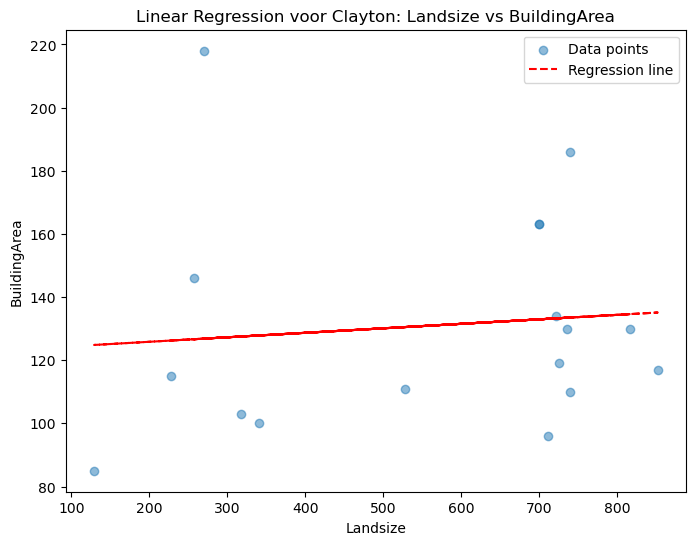

Linear Regression Model voor Clayton:
Slope: 0.01
Intercept: 122.99
Pearson Correlation: 0.10


In [76]:
filtered_df = MelbourneFullBaseDF.dropna(subset=['Landsize', 'BuildingArea'])
clayton_df = filtered_df[filtered_df['Suburb'] == 'Clayton']

if len(clayton_df) > 0:
    X = clayton_df['Landsize'].values.reshape(-1, 1)
    y = clayton_df['BuildingArea'].values
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    plt.figure(figsize=(8, 6))
    plt.scatter(clayton_df['Landsize'], clayton_df['BuildingArea'], label='Data points', alpha=0.5)
    plt.plot(clayton_df['Landsize'], y_pred, color='red', label='Regression line', linestyle='--')
    plt.xlabel('Landsize')
    plt.ylabel('BuildingArea')
    plt.title('Linear Regression voor Clayton: Landsize vs BuildingArea')
    plt.legend()
    plt.show()

    print(f"Linear Regression Model voor Clayton:")
    print(f"Slope: {model.coef_[0]:.2f}")
    print(f"Intercept: {model.intercept_:.2f}")
    print(f"Pearson Correlation: {clayton_df['Landsize'].corr(clayton_df['BuildingArea']):.2f}")
else:
    print("No data available for 'Clayton'.")

Bovenstaande weergave en bijbehorende informatie laat zien dat de relatie ontzettend zwak is, wat betekend dat deze imputatie methode niet geschikt is om deze missende waardes te bepalen.

Een mogelijke oplossing is om in te zien wat de numerieke verschillen tussen de twee waardes in dezelfde rij zijn, zodat er mogelijk daar een relatie kan worden g

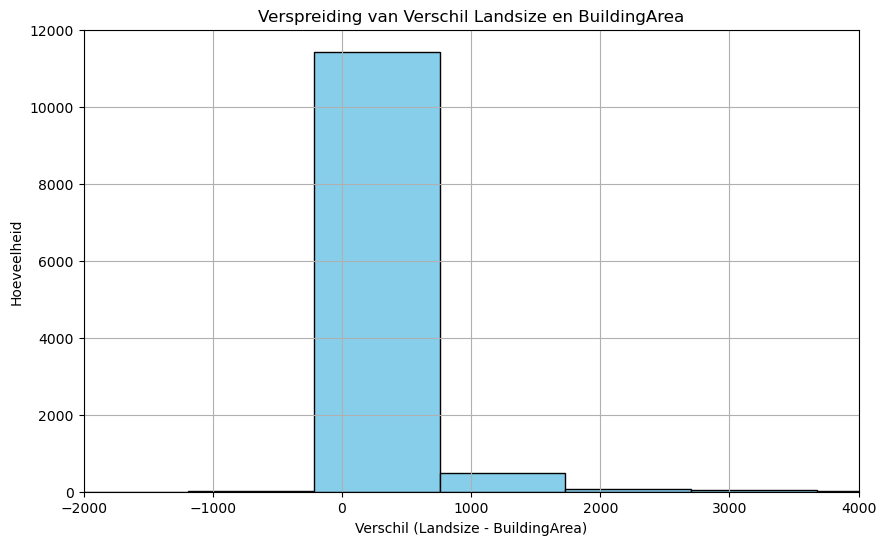

In [78]:
filtered_df = MelbourneFullBaseDF.dropna(subset=['Landsize', 'BuildingArea']).copy()

filtered_df['Difference'] = filtered_df['Landsize'] - filtered_df['BuildingArea']

plt.figure(figsize=(10, 6))
plt.hist(filtered_df['Difference'], bins=50, color='skyblue', edgecolor='black')
plt.xlim(-2000, 4000)
plt.xlabel('Verschil (Landsize - BuildingArea)')
plt.ylabel('Hoeveelheid')
plt.title('Verspreiding van Verschil Landsize en BuildingArea')
plt.grid(True)
plt.show()

Bovenstaande visualisatie geeft de verspreiding van de verschillen weer, waarbij het duidelijk is dat er een redelijk normale verspreiding van waardes aanwezig is. Echter zijn er ook een aantal waardes die vreemd zijn, die eigenlijk niet zouden moeten kloppen. Het is belangrijk om in kaart te brengen hoeveel van deze waardes aanwezig zijn, en of deze mogelijk kunnen zorgen voor verstoringen in het imputatie proces.

In het histogram is af te lezen dat de weinig aantallen gebeuren rondom 1800. Deze hoeveelheden zullen in een ander histogram worden weergegeven:

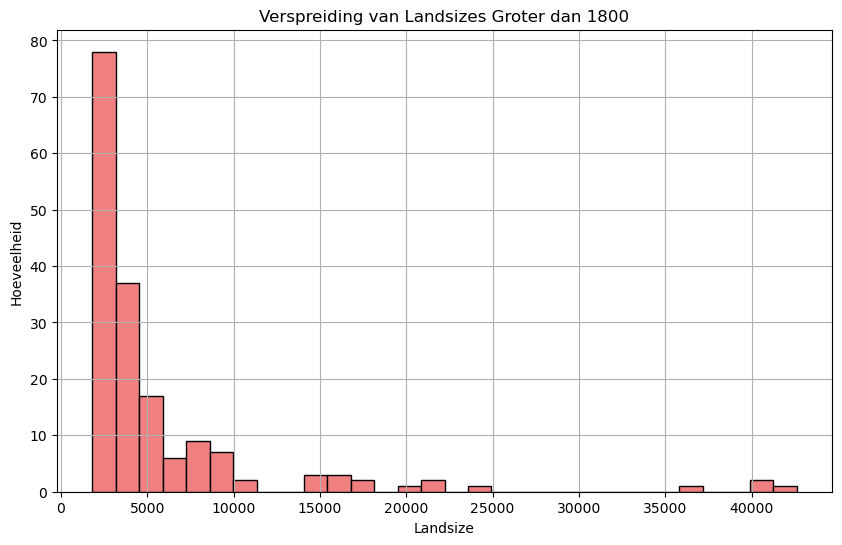

Total properties with Landsize > 1800: 172 (1.42%) out of 12140


In [80]:
large_difference_df = filtered_df[filtered_df['Difference'] > 1800]

plt.figure(figsize=(10, 6))
plt.hist(large_difference_df['Difference'], bins=30, color='lightcoral', edgecolor='black')
plt.xlabel('Landsize')
plt.ylabel('Hoeveelheid')
plt.title('Verspreiding van Landsizes Groter dan 1800')
plt.grid(True)
plt.show()

num_large_properties = large_difference_df.shape[0]
total_properties = filtered_df.shape[0]
percentage = (num_large_properties / total_properties) * 100

print(f'Total properties with Landsize > 1800: {num_large_properties} ({percentage:.2f}%) out of {total_properties}')

Uit dit histogram is af te lezen dat er een maar een klein aantal waardes (1.42%) bestaat uit uitschieters, wat betekend dat deze verwaarloosd kunnen worden in de overweging binnenin de imputatie.

Nu dat alle waardes voor de verschillende wijken geverifieerd is, kan deze worden toegepast op de missende waardes.
Als het ware kunnen de waardes geïmputeerd worden door de formules om te draaien:

De originele formule is <b>Verschil = Landsize - BuildingArea</b>

Omdraaien wordt het <b>BuildingArea = Landsize - Verschil</b>

En de andere vorm is <b>Landsize = BuildingArea + Verschil</b>

Deze formules zullen worden toegepast om missende data te imputeren.

In [82]:
filtered_df = MelbourneFullBaseDF.dropna(subset=['Landsize', 'BuildingArea']).copy()

filtered_df['Landsize'] = pd.to_numeric(filtered_df['Landsize'], errors='coerce')
filtered_df['BuildingArea'] = pd.to_numeric(filtered_df['BuildingArea'], errors='coerce')

filtered_df = filtered_df.dropna(subset=['Landsize', 'BuildingArea']).copy()
filtered_df['Landsize'] = filtered_df['Landsize'].astype(int)
filtered_df['BuildingArea'] = filtered_df['BuildingArea'].astype(int)
filtered_df['Difference'] = filtered_df['Landsize'] - filtered_df['BuildingArea']
suburb_median_difference = filtered_df.groupby('Suburb')['Difference'].median().to_dict()

In [83]:
import pandas as pd

def impute_building_area_and_landsize(df):
    filtered_df = df.dropna(subset=['Landsize', 'BuildingArea']).copy()
    filtered_df['Landsize'] = pd.to_numeric(filtered_df['Landsize'], errors='coerce')
    filtered_df['BuildingArea'] = pd.to_numeric(filtered_df['BuildingArea'], errors='coerce')
    filtered_df = filtered_df.dropna(subset=['Landsize', 'BuildingArea']).copy()
    filtered_df['Landsize'] = filtered_df['Landsize'].astype(int)
    filtered_df['BuildingArea'] = filtered_df['BuildingArea'].astype(int)
    filtered_df['Difference'] = filtered_df['Landsize'] - filtered_df['BuildingArea']
    suburb_median_difference = filtered_df.groupby('Suburb')['Difference'].median().to_dict()

    def impute_building_area(row):
        if pd.isna(row['BuildingArea']):
            median_diff = suburb_median_difference.get(row['Suburb'], None)
            if median_diff is not None:
                return row['Landsize'] - median_diff
        return row['BuildingArea']

    def impute_landsize(row):
        if pd.isna(row['Landsize']):
            median_diff = suburb_median_difference.get(row['Suburb'], None)
            if median_diff is not None:
                return row['BuildingArea'] + median_diff
        return row['Landsize']

    df['BuildingArea'] = df.apply(impute_building_area, axis=1)
    df['Landsize'] = df.apply(impute_landsize, axis=1)

    return df
    
MelbourneFullBaseDF = impute_building_area_and_landsize(MelbourneFullBaseDF)

In [84]:
missing_info = MelbourneFullBaseDF.isnull().sum().to_frame(name="Missing Values")
missing_info["Total Rows"] = len(MelbourneFullBaseDF)
missing_info["Percentage"] = (missing_info["Missing Values"] / missing_info["Total Rows"]) * 100

missing_info["Percentage"] = missing_info["Percentage"].map(lambda x: f"{x:.2f}%")
missing_info = missing_info.sort_values(by="Missing Values", ascending=False)

print(missing_info)

               Missing Values  Total Rows Percentage
YearBuilt               19306       34857     55.39%
BuildingArea            10233       34857     29.36%
Landsize                10214       34857     29.30%
Price                    7610       34857     21.83%
Suburb                      0       34857      0.00%
Bathroom                    0       34857      0.00%
Regionname                  0       34857      0.00%
Longitude                   0       34857      0.00%
Latitude                    0       34857      0.00%
CouncilArea                 0       34857      0.00%
Car                         0       34857      0.00%
Bedroom2                    0       34857      0.00%
Address                     0       34857      0.00%
Postcode                    0       34857      0.00%
Distance                    0       34857      0.00%
Date                        0       34857      0.00%
SellerG                     0       34857      0.00%
Method                      0       34857     

De waardes die over zijn gebleven zijn rijen die beiden waardes mistte of rijen waarvan de wijken geen data hadden.

Deze rijen zullen allereerst worden ingevuld op basis van de respectieve gemeente.

In [86]:
import pandas as pd

def impute_building_area_and_landsize(df):

    filtered_df = df.dropna(subset=['Landsize', 'BuildingArea']).copy()
    filtered_df['Landsize'] = pd.to_numeric(filtered_df['Landsize'], errors='coerce')
    filtered_df['BuildingArea'] = pd.to_numeric(filtered_df['BuildingArea'], errors='coerce')
    filtered_df = filtered_df.dropna(subset=['Landsize', 'BuildingArea']).copy()
    filtered_df['Landsize'] = filtered_df['Landsize'].astype(int)
    filtered_df['BuildingArea'] = filtered_df['BuildingArea'].astype(int)
    filtered_df['Difference'] = filtered_df['Landsize'] - filtered_df['BuildingArea']
    suburb_median_difference = filtered_df.groupby('Suburb')['Difference'].median().to_dict()

    def impute_building_area(row):
        if pd.isna(row['BuildingArea']):
            median_diff = suburb_median_difference.get(row['Suburb'], None)
            if median_diff is not None:
                return row['Landsize'] - median_diff
        return row['BuildingArea']

    def impute_landsize(row):
        if pd.isna(row['Landsize']):
            median_diff = suburb_median_difference.get(row['Suburb'], None)
            if median_diff is not None:
                return row['BuildingArea'] + median_diff
        return row['Landsize']

    df['BuildingArea'] = df.apply(impute_building_area, axis=1)
    df['Landsize'] = df.apply(impute_landsize, axis=1)

    return df

def impute_remaining_council(df):
    """Imputes remaining NaN values based on CouncilArea median difference."""

    council_median_diff = df.groupby('CouncilArea')['Difference'].median()

    def impute_row(row):
        if pd.isna(row['BuildingArea']) and pd.isna(row['Landsize']):
            return row['BuildingArea'], row['Landsize']
        elif pd.isna(row['BuildingArea']):
            median_diff = council_median_diff.get(row['CouncilArea'], 0)
            return row['Landsize'] - median_diff, row['Landsize']
        elif pd.isna(row['Landsize']):
            median_diff = council_median_diff.get(row['CouncilArea'], 0)
            return row['BuildingArea'], row['BuildingArea'] + median_diff
        else:
            return row['BuildingArea'], row['Landsize']

    df[['BuildingArea', 'Landsize']] = df.apply(impute_row, axis=1, result_type='expand')

    return df

MelbourneFullBaseDF = impute_building_area_and_landsize(MelbourneFullBaseDF)

MelbourneFullBaseDF['Difference'] = MelbourneFullBaseDF['Landsize'] - MelbourneFullBaseDF['BuildingArea']

MelbourneFullBaseDF = impute_remaining_council(MelbourneFullBaseDF)

In [87]:
missing_info = MelbourneFullBaseDF.isnull().sum().to_frame(name="Missing Values")
missing_info["Total Rows"] = len(MelbourneFullBaseDF)
missing_info["Percentage"] = (missing_info["Missing Values"] / missing_info["Total Rows"]) * 100

missing_info["Percentage"] = missing_info["Percentage"].map(lambda x: f"{x:.2f}%")
missing_info = missing_info.sort_values(by="Missing Values", ascending=False)

print(missing_info)

               Missing Values  Total Rows Percentage
YearBuilt               19306       34857     55.39%
Difference              10239       34857     29.37%
BuildingArea            10208       34857     29.29%
Landsize                10208       34857     29.29%
Price                    7610       34857     21.83%
Car                         0       34857      0.00%
Propertycount               0       34857      0.00%
Regionname                  0       34857      0.00%
Longitude                   0       34857      0.00%
Latitude                    0       34857      0.00%
CouncilArea                 0       34857      0.00%
Suburb                      0       34857      0.00%
Address                     0       34857      0.00%
Bedroom2                    0       34857      0.00%
Postcode                    0       34857      0.00%
Distance                    0       34857      0.00%
Date                        0       34857      0.00%
SellerG                     0       34857     

<h2><b>>50% Missende Waardes</b></h2>

De laatste kolommen die mogelijk geïmputeerd moeten worden zijn "BuildingArea" en "YearBuilt".

Beiden kolommen hebben waarschijnlijk een invloed op de woonprijs, en beiden zijn dus waardevolle data om te kunnen gebruiken binnenin de Machine Learning.

BuildingArea kan deels geïmputeerd worden gebaseerd op toegevoegde logica in de vorm van de overweging van ruimte-gerelateerde kolommen zoals "Landsize" en "Rooms". Deze kunnen namelijk een indicatie zijn voor minimale- en maximale waardes, waardoor de imputatie al veel sneller dichter bij de waarheid zal liggen.

YearBuilt is echter een waarde die veel moeilijker is om te achterhalen, de enige variabele waar een directe relatie mee zou moeten bestaan is de woonprijs, maar deze bevat ook een aantal missende waardes. Een enig onderzoek dat kan worden uitgevoerd is het bekijken of er bepaalde buitenwijken zijn waarin huizen met een specifiek bouwjaar vaker voorkomen, omdat huizen in een wijk vaak in eenzelfde periode zijn gebouwd.

<b>YearBuilt</b>

De eerste stap om dit onderzoek uit te voeren is door te werken met eenzelfde aanpak als met de breedte- en lengtegraad, waarbij er onderzoekend te werk wordt gegaan om een relatie te ontdekken tussen het bouwjaar en de verschillende gebieden. Hierbij wordt er steeds dieper ingezoomd op specifiekere gebieden om er zo achter te komen of er specifieke bouwjaren aanwezig zijn voor de huizen in dat gebied, om zo de imputatie zo specifiek mogelijk te krijgen.

Hiervoor wordt er eerst gekeken naar de Regio via "Regionname", daarna naar de specifieke gemeentes via "CouncilArea", en tenslotte naar de specifieke buitenwijken via "Suburb".

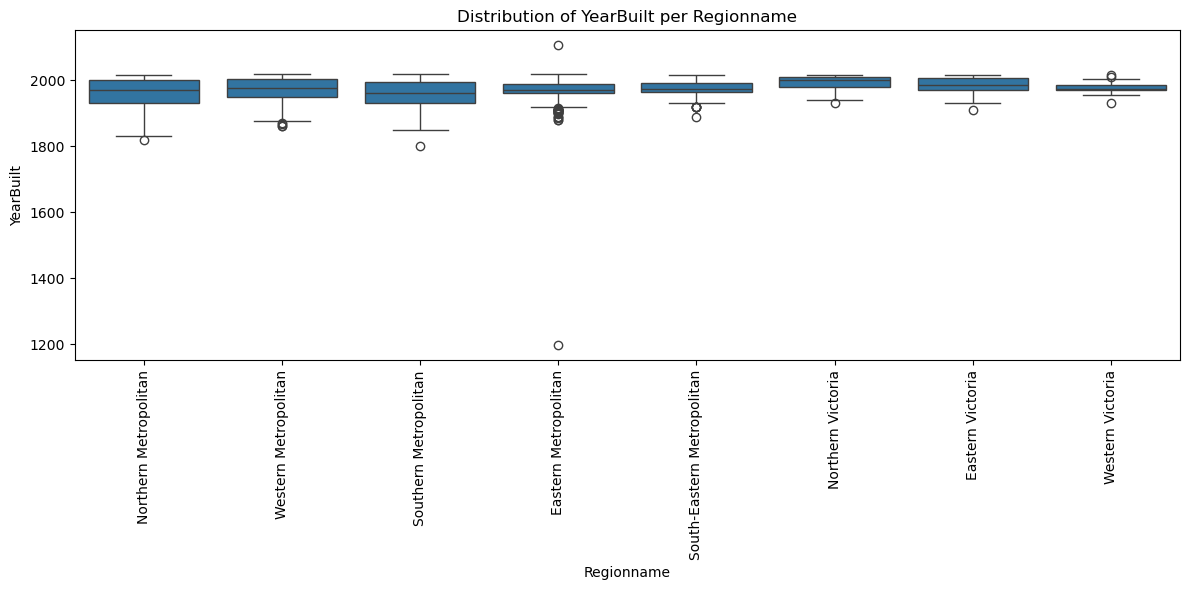

In [90]:
df_clean = MelbourneFullBaseDF.dropna(subset=['YearBuilt'])

plt.figure(figsize=(12, 6))

sns.boxplot(x='Regionname', y='YearBuilt', data=df_clean)
plt.title('Distribution of YearBuilt per Regionname')
plt.xlabel('Regionname')
plt.ylabel('YearBuilt')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Bovenstaande boxplots laten zien dat er wel degelijk een bepaalde verspreiding aanwezig is per regio die ook variëren van elkaar. Deze bevinding biedt de mogelijkheid om verder in te zoomen op de verschillende gemeentes binnenin de regio's.

Deze handeling biedt namelijk de mogelijkheid om te zien of er discrepanties in bouwjaar aanwezig zijn binnenin de regio, zodat er ook verder onderzocht kan worden of bepaalde wijken eenzelfde observatie bevatten.

Voor deze handeling zullen ook weer boxplots worden gecreëerd om de waardes per gebied te observeren.

<Figure size 1200x800 with 0 Axes>

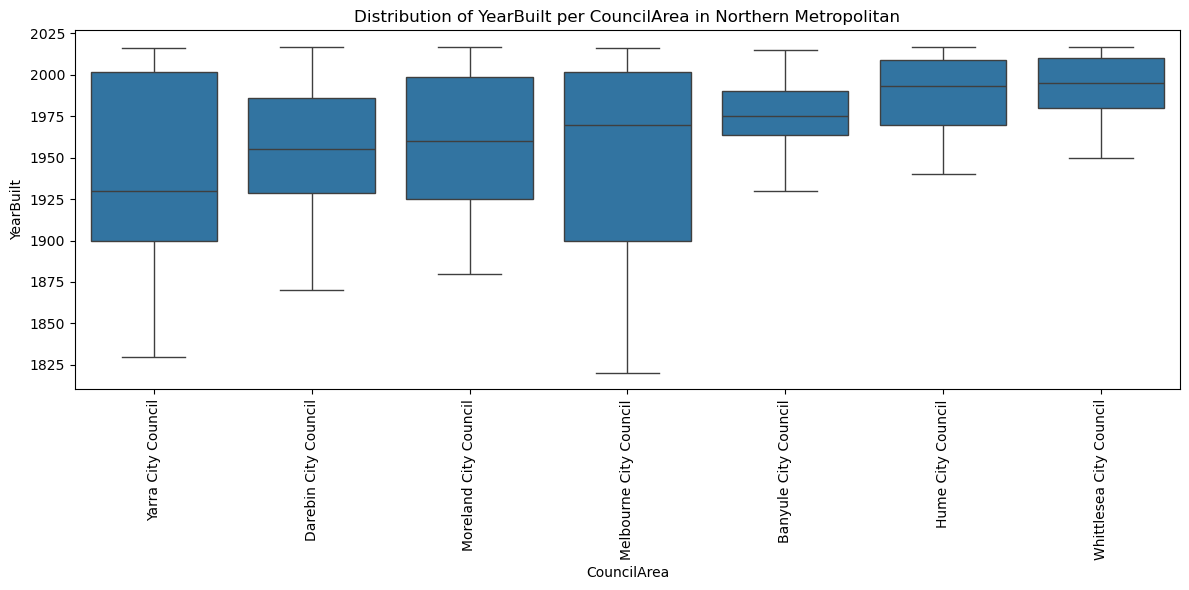

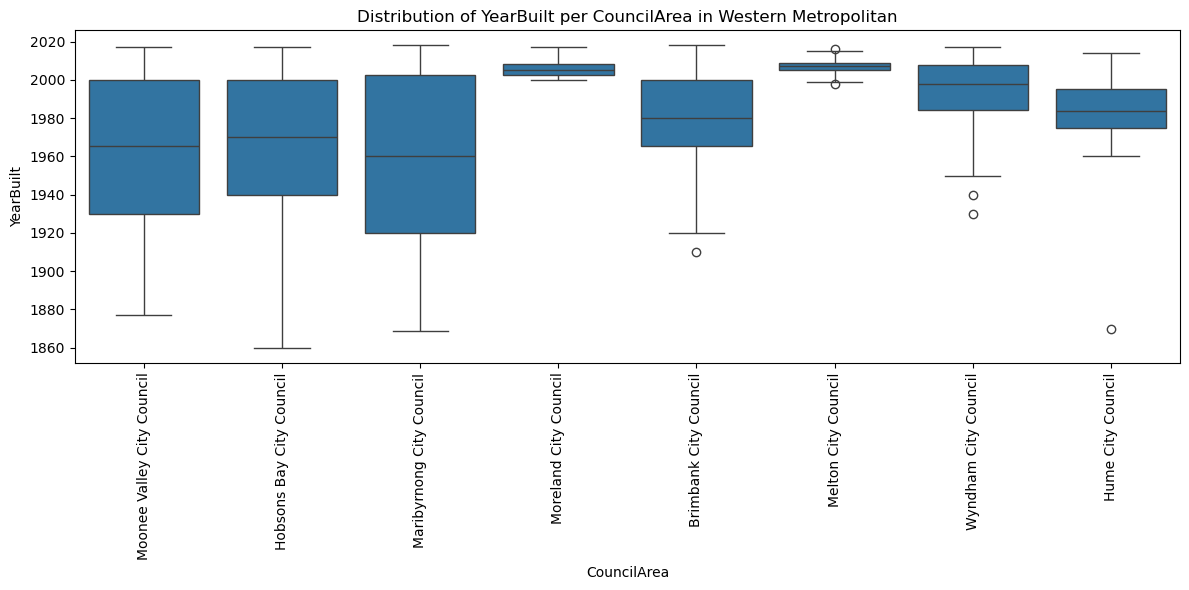

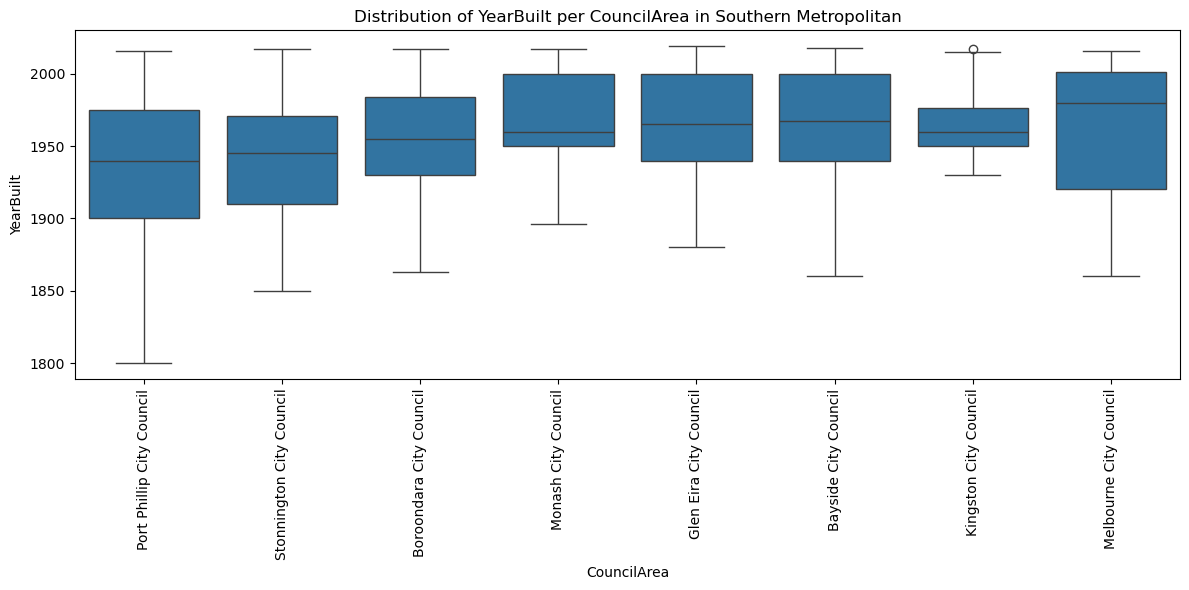

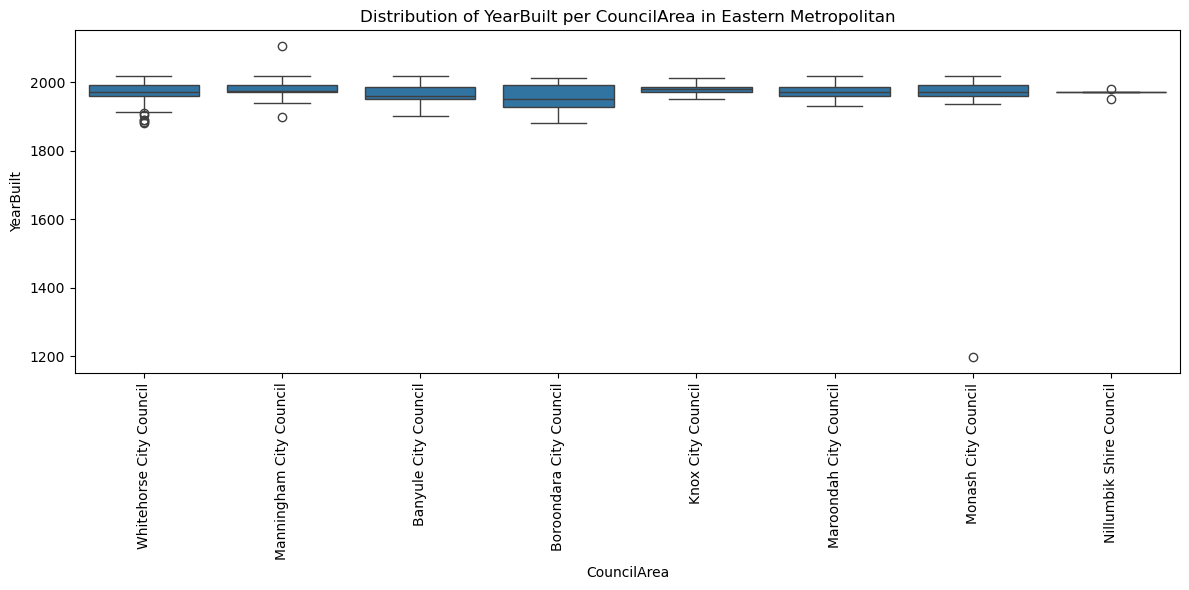

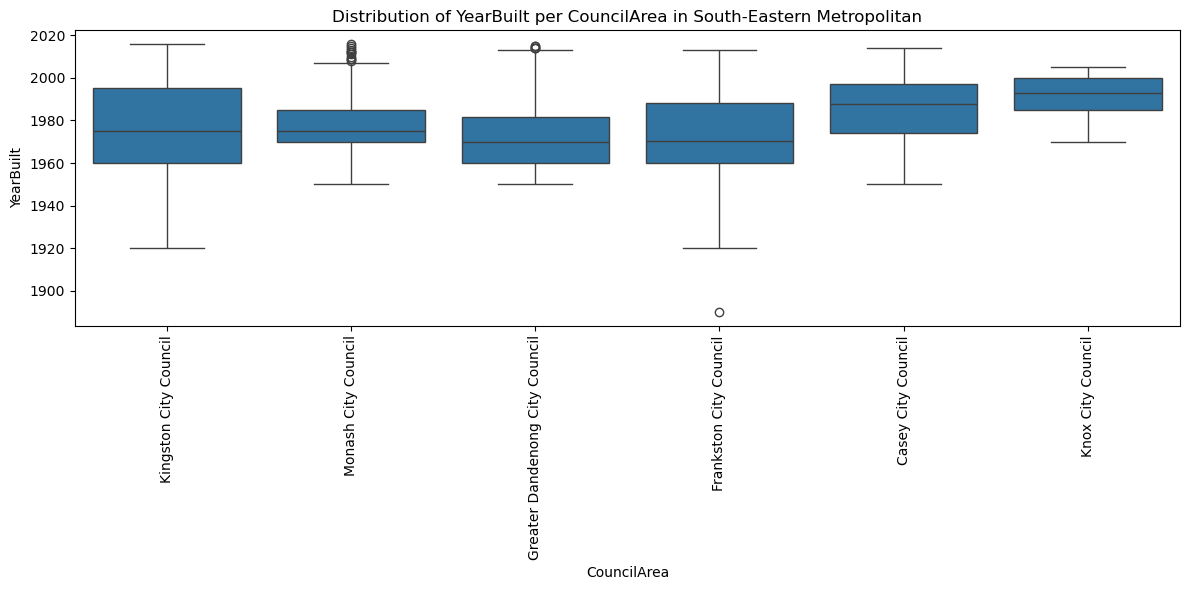

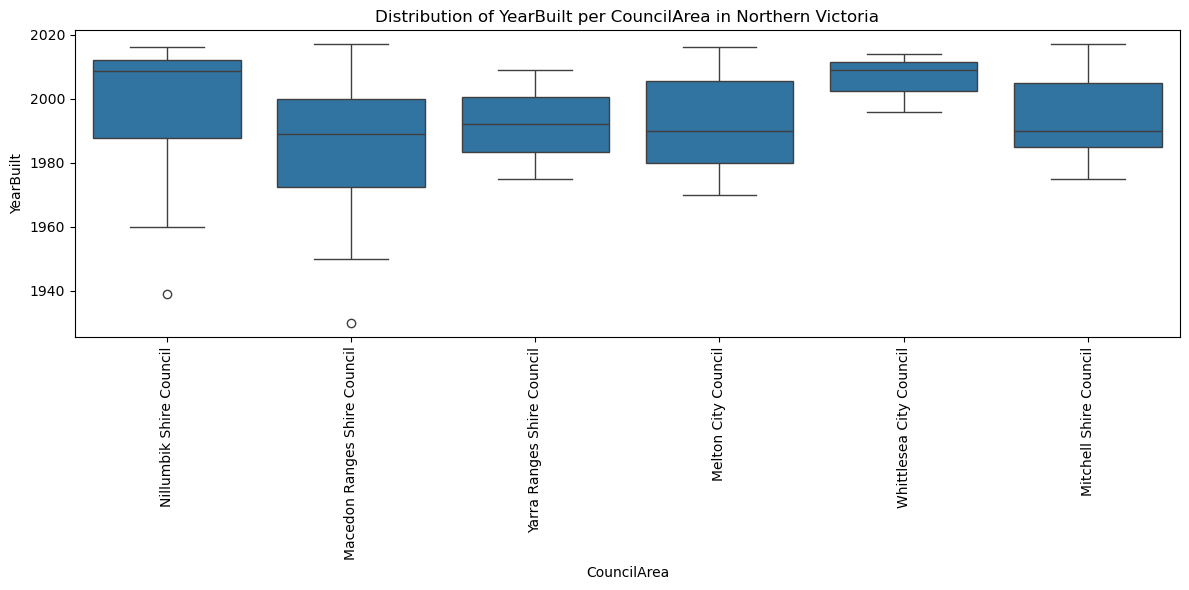

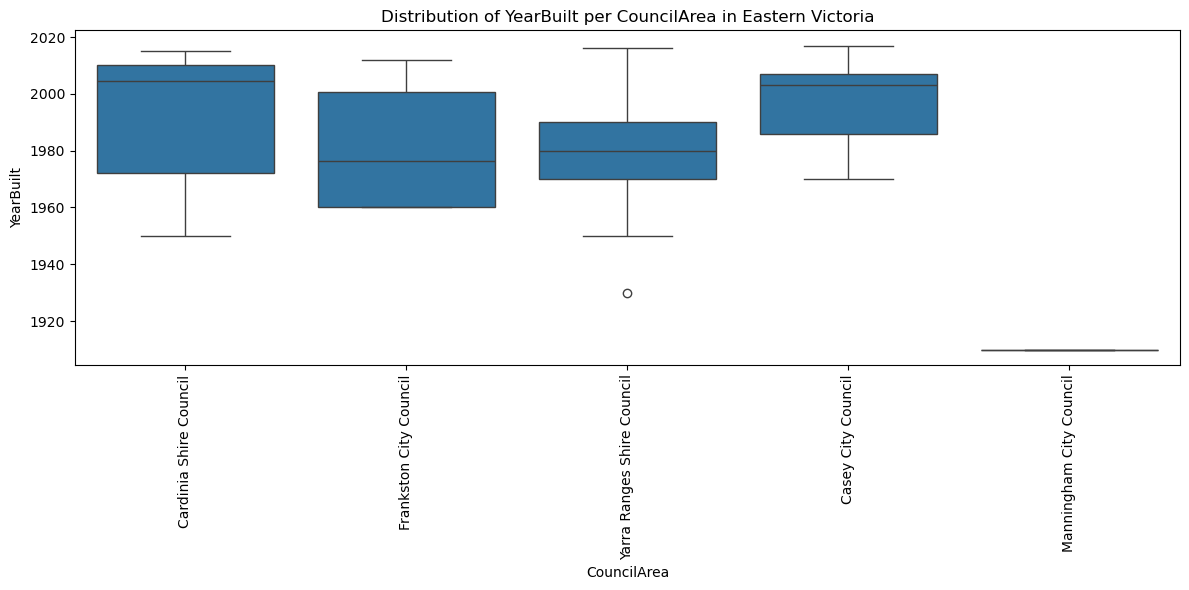

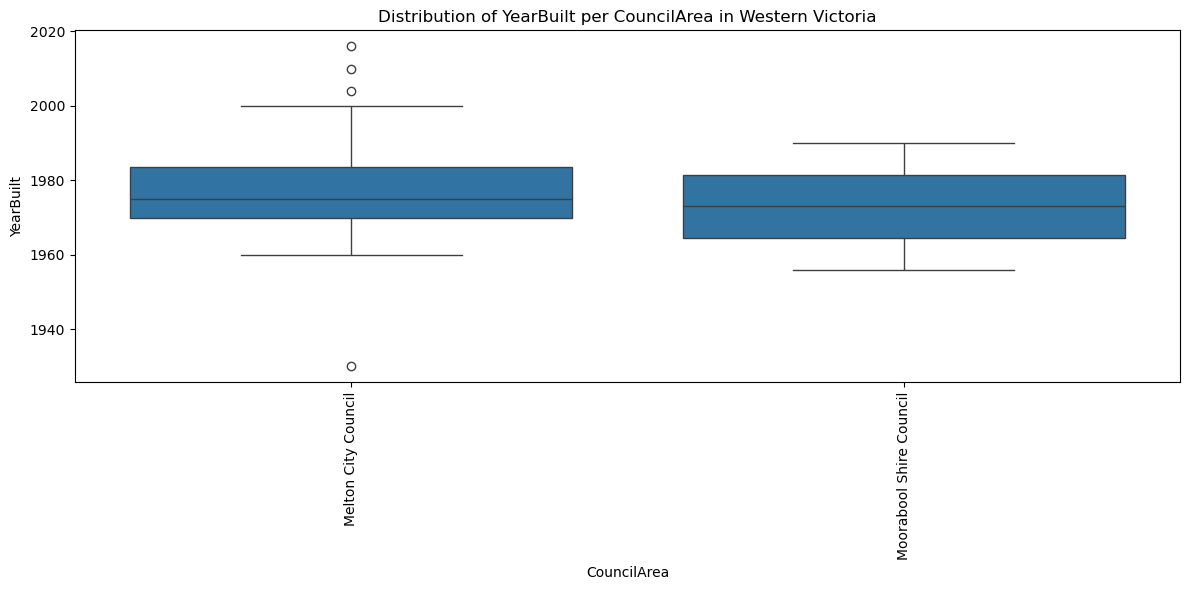

In [92]:
df_clean = MelbourneFullBaseDF.dropna(subset=['YearBuilt'])

regionnames = df_clean['Regionname'].unique()

plt.figure(figsize=(12, 8))

for region in regionnames:
    region_data = df_clean[df_clean['Regionname'] == region]
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='CouncilArea', y='YearBuilt', data=region_data)
    plt.title(f'Distribution of YearBuilt per CouncilArea in {region}')
    plt.xlabel('CouncilArea')
    plt.ylabel('YearBuilt')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

Ook deze visualisaties laten zien dat er bepaalde unieke verspreidingen aanwezig zijn binnenin elke gemeente, al zijn er gemeentes met grotere verspreidingen. Omdat de verschillende wijken veel minder resultaten bevat zal deze verspreiding veel smaller worden, wat er voor zorgt dat er een specifieker resultaat geïmputeerd kan worden.

Er zijn te veel gemeentes om weer te geven, wat betekend dat er alleen voorbeelden worden gegeven, hiervoor worden er willekeurig vier verschillende plots weergegeven.

<Figure size 1200x1200 with 0 Axes>

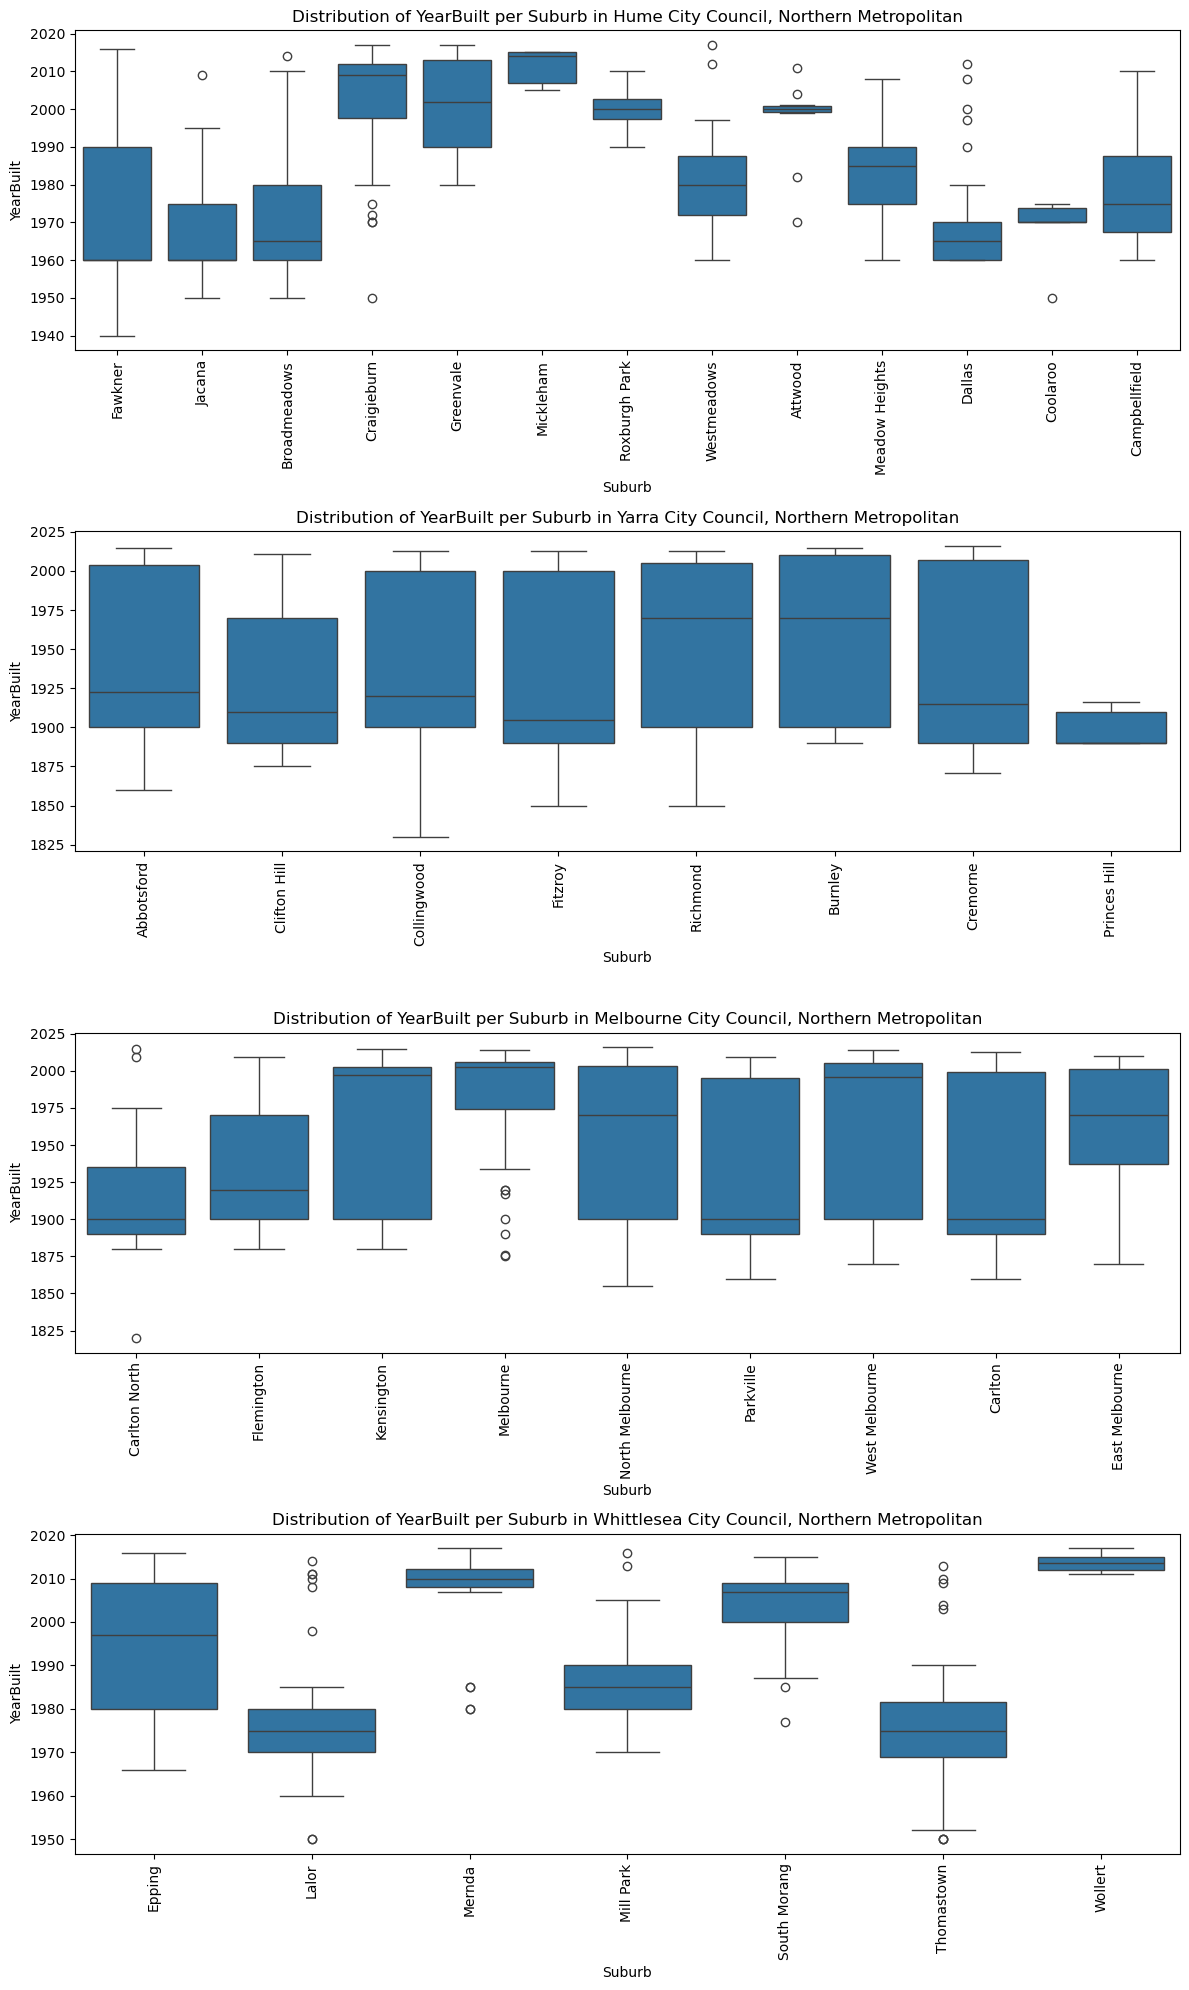

In [94]:
df_clean = MelbourneFullBaseDF.dropna(subset=['YearBuilt'])

regionnames = df_clean['Regionname'].unique()

plt.figure(figsize=(12, 12))

fig, axes = plt.subplots(4, 1, figsize=(12, 20))
axes = axes.flatten()

plot_idx = 0

for region in regionnames:
    region_data = df_clean[df_clean['Regionname'] == region]
    council_areas = region_data['CouncilArea'].unique()
    random_council_areas = random.sample(list(council_areas), 4)
    
    for council_area in random_council_areas:
        council_area_data = region_data[region_data['CouncilArea'] == council_area]
        sns.boxplot(x='Suburb', y='YearBuilt', data=council_area_data, ax=axes[plot_idx])
        axes[plot_idx].set_title(f'Distribution of YearBuilt per Suburb in {council_area}, {region}')
        axes[plot_idx].set_xlabel('Suburb')
        axes[plot_idx].set_ylabel('YearBuilt')
        axes[plot_idx].tick_params(axis='x', rotation=90)
        plot_idx += 1
        if plot_idx == 4:
            break

    if plot_idx == 4:
        break

plt.tight_layout()
plt.show()

Helaas valt er af te lezen dat er maar een aantal wijken zijn die een kleine verspreiding aan bouwjaar hebben, de meeste wijken lijken namelijk een verspreiding te hebben van een groot aantal jaren, wat het moeilijk maakt om een preciese waarde te imputeren.

Sommige boxplots hebben een verspreiding waaruit duidelijk naar voren komt dat de verdeling van de bouwjaren vooral hoog of laag ligt binnenin de respectieve wijk, maar een groot aantal boxplots hebben de waardes gewoonweg ongeveer in het midden liggen.

Om deze reden is het niet mogelijk om de imputatie-methode te gebruiken die voor de breedte- en lengtegraad is toegepast, in dat de verspreiding veel te groot is. Echter moeten de waardes toch in worden gevuld voor de toepassing van Regression op het bepalen van de woningsprijs.

Om toch de waardes in te kunnen vullen, wordt een andere vorm van Machine Learning gebruikt voor de invulling van het bouwjaar. In principe is er nog steeds het idee dat woningen in een bepaalde wijk vaak eenzelfde soort huizen zijn, en dat daarbij eenzelfde bouwjaar hoort.

Omdat dit niet duidelijk naar voren komt wanneer alleen naar de wijk wordt gekeken, zal er verder gekeken worden naar de andere factoren binnenin de rijen. De Machine Learning methode die wordt toegepast, K-Nearest Neighbor, zal een bouwjaar invullen gebaseerd op overeenkomende factoren binnenin dezelfde wijk.

Deze Machine Learning zal dus later worden toegepast.

<b>BuildingArea</b>

De laatste kolom die nog moet worden ingevuld is BuildingArea. Zoals eerder is neergeschreven kan BuildingArea deels worden geïmputeerd op basis van andere factoren in de dataset zoals Landsize, Rooms, en Price.

In [96]:
train_data = MelbourneFullBaseDF.dropna(subset=["BuildingArea", "Price", "Rooms", "Landsize"]).copy()
 
X_train = train_data[["Rooms", "Landsize", "Price"]].copy()
y_train = train_data["BuildingArea"].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
 
regressor = LinearRegression()
regressor.fit(X_train_scaled, y_train)
 
missing_idx = MelbourneFullBaseDF[ (MelbourneFullBaseDF["BuildingArea"].isna()) & (MelbourneFullBaseDF["Price"].notna()) & (MelbourneFullBaseDF["Rooms"].notna()) & (MelbourneFullBaseDF["Landsize"].notna()) ].index
 
if not missing_idx.empty:
    X_missing = MelbourneFullBaseDF.loc[missing_idx, ["Rooms", "Landsize", "Price"]].copy()
    X_missing_scaled = scaler.transform(X_missing)
    MelbourneFullBaseDF.loc[missing_idx, "BuildingArea"] = regressor.predict(X_missing_scaled)
else:
    print("No rows with missing BuildingArea but complete predictors found.")
 
print(MelbourneFullBaseDF)

NameError: name 'StandardScaler' is not defined

<div id=section5>
<h2><b>Modelkeuze en Implementatie</b></h2>

Het doel van dit rapport is om te kunnen voorspellen wat een uiteindelijke prijs voor een woning kan zijn wanneer veel verschillende factoren worden geëvalueerd.

De prijs is een continue waarde die afhankelijk is van een lineaire relatie met andere waardes zoals de hoeveelheid land, het bouwjaar, en de hoeveelheid kamers. Deze relatie is redelijk lineair want er valt te verwachten dat een grotere hoeveelheid land of een ouder huis de prijs laat stijgen.

Echter zijn er ook variabelen die geen lineaire relatie kunnen hebben met de prijs, dit zijn categorische waardes die niet op die manier geïnterpreteerd kunnen worden. Waardes zoals de locatie en het type woning zullen zeker invloed hebben op de prijs, maar zijn niet toepasbaar op een Lineaire regressie model.

Tenslotte is er ook de ondervinding dat het logisch is dat bepaalde huizen op een bepaalde locatie, met dezelfde elementen vaak eenzelfde prijs zullen hebben, dit zou dan ook een manier kunnen zijn om een prijs te bepalen.

Deze manieren sluiten aan op de volgende algoritmes die geëvalueerd zullen worden voor gebruik met deze dataset:

- <b>Linear Regression</b>
- <b>Random Forest</b>
- <b>Support Vector Machines</b>
- <b>K-Nearest Neighbor</b>

Deze algoritmes zullen eerst kort worden omschreven in de vorm van voor- en nadelen, waarna er wordt uitgelegd hoe het model zal worden getraind, en welke hyperparameters mogelijk zijn voor installatie.

<b>Linear Regression</b>

De lineaire regressie is een simpel basismodel om prijzen te voorspellen gebaseerd op factoren die een lineaire relatie met de woningsprijs hebben, voor dit model worden waardes zoals BuildingArea en YearBuilt gebruikt.

Dit model heeft de volgende voordelen:

- Het model is simpel en makkelijk te trainen.
- Het model is erg makkelijk te verklaren en onderbouwen gebaseerd op formules.
- Het model werkt goed wanneer de relaties lineair zijn.

Dit model heeft de volgende nadelen:

- Het model gaat uit van een lineaire relatie, die mogelijk niet aanwezig is.
- Het model is gevoelig voor Multicollineariteit, een observatie dat de verklarende variabelen een te sterk lineair verband hebben dat de coëfficiënt verslechterd.
- Het model is gevoelig voor uitschieters.

Het model wordt op de volgende manier getraind:

1. Datavoorbereiding

- Toepassing van One-Hot encoding voor de categorische waardes.
- Toepassing van een schaal op de numerieke waardes.
- Elementaire invulling van nog-steeds missende waardes.

2. Data Split

- Splitsing van dataset in een 80/20 verhouding, waarbij 80% van de dataset wordt gebruikt voor het trainen van de AI.

3. Model Training

- Gebruik van de Ordinary Least Squares training set, een training set die zich goed aansluit op lineaire regressie, in dat deze de waardes die bij de normale regressie formule horen in zijn geheel uitschrijft.

4. Evaluatie

- Evaluatiemetrieken in de vorm van Mean Squared Error en de R² Score.
- Een lage MSE betekend meer nauwkeurigheid dan een hoge MSE.
- Een R² Score die dicht bij 1 ligt houdt in dat het model grotendeels de variantie uit kan leggen, hoe minder deze score is, hoe minder patronen aanwezig zijn voor de lineaire regressie.
- Een grote discrepantie tussen de respectieve scores in de training en test set zouden een aanwijzing voor de aanwezigheid van Overfitting kunnen zijn.
- Wanneer de R² Scores voor de training en test set beiden laag zijn, maar de MSE voor beiden hoog is, kan er Underfitting aanwezig zijn.

5. Parameters

- Indien nodig, een weglating van overbodige kolommen.

De volgende stappen zullen deze training weergeven, de evaluatie zal worden uitgevoerd nadat alle andere algoritmes zijn geprobeerd.

Allereerst is het belangrijk om te checken of alle datatypes nog correct zijn.

In [97]:
MelbourneFullBaseDF.dtypes

Suburb                   object
Address                  object
Rooms                     int64
Type                     object
Price                    object
Method                   object
SellerG                  object
Date             datetime64[ns]
Distance                float64
Postcode                 object
Bedroom2                float64
Bathroom                float64
Car                       int64
Landsize                 object
BuildingArea             object
YearBuilt                object
CouncilArea              object
Latitude                float64
Longitude               float64
Regionname               object
Propertycount           float64
Difference               object
dtype: object

Er is te zien dat Landsize, BuildingArea, YearBuilt, en de nieuwe aangemaakte kolom "Difference" allemaal een object als datatype hebben omdat dit niet terug was geconverteerd na onze imputatie. Dit zal dan nu moeten gebeuren.

In [99]:
MelbourneFullBaseDF['Landsize'] = pd.to_numeric(MelbourneFullBaseDF['Landsize'], errors='coerce').astype('float64')
MelbourneFullBaseDF['BuildingArea'] = pd.to_numeric(MelbourneFullBaseDF['BuildingArea'], errors='coerce').astype('float64')
MelbourneFullBaseDF['Difference'] = pd.to_numeric(MelbourneFullBaseDF['Difference'], errors='coerce').astype('float64')
MelbourneFullBaseDF['YearBuilt'] = pd.to_numeric(MelbourneFullBaseDF['YearBuilt'], errors='coerce').astype('float64')

print(MelbourneFullBaseDF.dtypes)

Suburb                   object
Address                  object
Rooms                     int64
Type                     object
Price                    object
Method                   object
SellerG                  object
Date             datetime64[ns]
Distance                float64
Postcode                 object
Bedroom2                float64
Bathroom                float64
Car                       int64
Landsize                float64
BuildingArea            float64
YearBuilt               float64
CouncilArea              object
Latitude                float64
Longitude               float64
Regionname               object
Propertycount           float64
Difference              float64
dtype: object


Nu dat alle kolommen weer het correcte datatype hebben, kan het stappenplan worden uitgevoerd. Beginnende met de voorbereiding van de data.

<b>Stap 1: Datavoorbereiding</b>

Eerst zullen de numerieke kolommen worden geselecteerd gebaseerd op de mogelijkheid dat er een lineaire regressie aan te tonen valt. Hierbij worden alle numerieke kolommen geselecteerd, behalve Longitude en Latitude, omdat deze zonder context niks toevoegen. Daarnaast bevat YearBuilt nog te veel missende waardes, en zal deze in een latere toepassing pas worden geïntegreerd in het model.

Ook belangrijk is de toepassing van One-Hot encoding op de categorische kolommen, de categorische kolommen die voor de voorspelling een toevoeging kunnen hebben zijn als volgt:

- Type
- CouncilArea
- Method
- Suburb
- Regionname

Tenslotte zijn er nog kolommen die belangrijk zijn voor de regressie maar toch nog data missen, waaronder de oppervlakte kolommen. Deze kolommen zullen elementair worden ingevuld gebaseerd op een simpele imputatie.

Daarnaast mist de Prijs kolom ongeveer 20% van de data, maar deze zullen dan worden gebruikt voor de test set.

In [101]:
features = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea']
categorical_features = ['Suburb', 'Type', 'Regionname', 'Method', 'CouncilArea']
target = 'Price'

columns_to_impute = ['BuildingArea', 'Landsize']
imputer = SimpleImputer(strategy='mean')
MelbourneFullBaseDF[columns_to_impute] = imputer.fit_transform(MelbourneFullBaseDF[columns_to_impute])

df_encoded = pd.get_dummies(MelbourneFullBaseDF[features + categorical_features], drop_first=True)

<b>Stap 2: Data Split</b>

De volgende stap betreft het splitsen van de data, hiervoor zullen alle rijen met missende waardes voor Prijs gebruikt worden in een latere test set. Om dit te doen moeten deze eerst uitgelicht worden.

Daarna zullen de waardes binnenin de training data 80/20 worden gesplitst.

In [103]:
train_valid_df = MelbourneFullBaseDF.dropna(subset=['Price'])
test_df = MelbourneFullBaseDF[MelbourneFullBaseDF['Price'].isna()]

print("Training + Validatie Data Grootte:", train_valid_df.shape)
print("Test Data (Zonder Prijs) Grootte:", test_df.shape)

X = df_encoded.loc[train_valid_df.index]
y = train_valid_df['Price']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Set Grootte:", X_train.shape)
print("Validation Set Grootte:", X_valid.shape)

Training + Validatie Data Grootte: (27247, 22)
Test Data (Zonder Prijs) Grootte: (7610, 22)
Training Set Grootte: (21797, 406)
Validation Set Grootte: (5450, 406)


In bovenstaande print is te zien dat er 384 extra kolommen zijn toegevoegd doormiddel van de One-Hot Encoding.

<b>Stap 3: Model Training</b>

De volgende stap betreft de training van het model, hiervoor wordt een methode toegepast die het beste past bij de lineaire regressie in de vorm van Ordinary Least Sqaures (OLS).

Dit model zal een samenvatting genereren waaruit voortkomt hoe sterk elke relatie met de woonprijs is. Deze samenvatting bevat informatie over de volgende data:

- Coëfficiënten: De invloed van elke kolom op de woonprijs.
- P-waardes:
- Determinatiecoëfficiënt:
- F-waardes:

Allereerst zal nog worden gecheckt of de data geschikt is voor het model, in dat alles numeriek moet zijn, hiervoor zullen de kolommen met het object datatype weg worden gehaald nu dat deze One-Hot encoded zijn.

In [109]:
columns_to_remove = [
    'Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 
    'Postcode', 'CouncilArea', 'Regionname', 'Difference', 'YearBuilt'
]

X_train = X_train.drop(columns=columns_to_remove, errors='ignore')
X_valid = X_valid.drop(columns=columns_to_remove, errors='ignore')

y_train = pd.to_numeric(y_train, errors='coerce')
y_valid = pd.to_numeric(y_valid, errors='coerce')

In [117]:
boolean_columns = X_train.select_dtypes(include='bool').columns
X_train[boolean_columns] = X_train[boolean_columns].astype(int)
X_valid[boolean_columns] = X_valid[boolean_columns].astype(int)

X_train_with_const = sm.add_constant(X_train)
X_valid_with_const = sm.add_constant(X_valid)

In [123]:
ols_model = sm.OLS(y_train, X_train_with_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     121.0
Date:                Tue, 01 Apr 2025   Prob (F-statistic):               0.00
Time:                        17:42:34   Log-Likelihood:            -3.1038e+05
No. Observations:               21797   AIC:                         6.215e+05
Df Residuals:                   21445   BIC:                         6.243e+05
Df Model:                         351                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------